# Universidade Positivo
## Avaliação — Data Science
### Governança de Dados, Estatística Descritiva e Inferencial aplicadas ao Wine Recognition Dataset

| | |
|---|---|
| **Disciplina** | Data Science |
| **Professor(a)** | Leandro Escobar |
| **Aluno(a)** | ____________________________________________ |
| **RA** | ____________________________________________ |
| **Data de aplicação** | 16/09/2026 |
| **Prazo de entrega** | 23/09/2026, até 23h59, via Blackboard |
| **Valor** | 2,5 pontos |
| **Forma de entrega** | Relatório técnico único, em formato .pdf ou .docx |
| **Consulta** | Material de aula, documentação oficial das bibliotecas e ferramentas de IA generativa (mediante entrega dos prompts) |

---

Este notebook constitui o relatório técnico único desta avaliação, utilizando o *Wine Recognition
Dataset* (FORINA et al., 1991), carregado via `sklearn.datasets.load_wine`, exatamente como
demonstrado na Aula 03. O uso de IA generativa foi permitido como apoio à escrita do código, à
depuração de erros e à interpretação dos resultados, condicionado à entrega de todos os prompts
utilizados, anexos em `prompts.txt`, indicando a qual questão cada prompt se refere.

O relatório está organizado de modo que cada questão prática apresente, nesta ordem: o enunciado do
item, a **escolha metodológica** adotada e seu critério técnico, o código, as saídas numéricas e
gráficas, e o parágrafo de **interpretação** dos resultados. As respostas das questões teóricas
(1 a 3) são entregues em documento separado. Todas as figuras são exibidas no notebook e também
exportadas para a pasta `figuras/`.

### Distribuição de pontos

| Questão | Tema | Tipo | Valor |
|---|---|---|---|
| 1 | Governança de dados e LGPD | Teórica | 0,2 |
| 2 | Amostragem, distribuição e medidas descritivas | Teórica | 0,2 |
| 3 | Correlação e testes de hipótese | Teórica | 0,2 |
| 4 | Amostragem estratificada e Teorema Central do Limite | Prática | 0,3 |
| 5 | Medidas de posição, dispersão e outliers | Prática | 0,3 |
| 6 | Forma da distribuição e normalidade | Prática | 0,3 |
| 7 | Correlação, significância e redundância | Prática | 0,25 |
| 8 | Teste de hipótese entre 2 grupos | Prática | 0,25 |
| 9 | ANOVA/Kruskal-Wallis com post-hoc | Prática | 0,25 |
| 10 | Questão integradora | Prática | 0,25 |
| **Total** | | | **2,5** |


## Configuração global e funções auxiliares

**Escolha metodológica:** define-se uma seed fixa (`SEED = 42`) para todas as operações estocásticas
(amostragens, reamostragens) e um gerador `np.random.default_rng` dedicado ao bootstrap da Questão 4,
garantindo reprodutibilidade integral do notebook. O nível de significância adotado em todos os testes
de hipótese é `ALPHA = 0.05`.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------- Configurações globais -------------------------
SEED = 42
ALPHA = 0.05
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("figuras", exist_ok=True)

ORDEM_CULTIVARES = ["Cultivar A", "Cultivar B", "Cultivar C"]


# ------------------------- Funções auxiliares -------------------------
def salvar_figura(nome_arquivo):
    """Salva a figura atual em figuras/<nome_arquivo> (dpi=150) e a exibe no notebook."""
    plt.tight_layout()
    plt.savefig(f"figuras/{nome_arquivo}", dpi=150, bbox_inches="tight")
    plt.show()


def cv_percent(series, ddof=1):
    """Coeficiente de variação em porcentagem: 100 * desvio-padrão / média."""
    return 100 * series.std(ddof=ddof) / series.mean()


def iqr_outliers(series):
    """Máscara booleana de outliers pela regra 1,5*IQR, e os limites inferior/superior."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper


def shapiro_by_group(dataframe, group_col, value_col, alpha=ALPHA):
    """Teste de Shapiro-Wilk aplicado a cada grupo de group_col para value_col."""
    linhas = []
    for grupo, sub in dataframe.groupby(group_col, observed=True):
        stat, p = stats.shapiro(sub[value_col])
        linhas.append({
            "grupo": grupo, "n": len(sub), "W": stat, "p_valor": p,
            "normal (p>alpha)": p > alpha,
        })
    return pd.DataFrame(linhas)


def eta_squared_oneway(*grupos):
    """Eta-quadrado para ANOVA one-way: SQ_entre / SQ_total."""
    todos = np.concatenate(grupos)
    media_geral = todos.mean()
    sq_total = np.sum((todos - media_geral) ** 2)
    sq_entre = sum(len(g) * (np.mean(g) - media_geral) ** 2 for g in grupos)
    return sq_entre / sq_total


def epsilon_squared_kruskal(H, n):
    """Epsilon-quadrado para Kruskal-Wallis: H*(n+1)/(n**2-1) (King & Minium, 2003)."""
    return H * (n + 1) / (n ** 2 - 1)


def ic95_media(series):
    """Intervalo de confiança de 95% para a média (distribuição t, ddof=1)."""
    n = len(series)
    m = series.mean()
    se = series.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1)
    return m - tcrit * se, m + tcrit * se

## Preparação dos dados

Os dados são carregados diretamente de `sklearn.datasets.load_wine`, que reúne 178 amostras de vinhos
de três cultivares distintas, caracterizadas por 13 variáveis físico-químicas contínuas. O alvo (`target`,
valores 0/1/2) é mapeado para os rótulos `Cultivar A`, `Cultivar B` e `Cultivar C`, respectivamente.

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()

cultivar_map = {0: "Cultivar A", 1: "Cultivar B", 2: "Cultivar C"}
df["cultivar"] = df["target"].map(cultivar_map)

feature_cols = list(wine.feature_names)

print(f"Dimensões do DataFrame: {df.shape}")
df.head()

Dimensões do DataFrame: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0,Cultivar A
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0,Cultivar A
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0,Cultivar A
3,14.3700,1.9500,2.5000,16.8000,113.0000,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480.0000,0,Cultivar A
4,13.2400,2.5900,2.8700,21.0000,118.0000,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735.0000,0,Cultivar A


In [3]:
contagem = df["cultivar"].value_counts().reindex(ORDEM_CULTIVARES)
contagem_df = contagem.rename("n_amostras").to_frame()
contagem_df["proporcao (%)"] = 100 * contagem_df["n_amostras"] / len(df)
contagem_df.round(4)

,n_amostras,proporcao (%)
cultivar,,
Cultivar A,59,33.1461
Cultivar B,71,39.8876
Cultivar C,48,26.9663


# Questão 1 — Governança de Dados e LGPD (Valor: 0,2 ponto)

Uma vinícola decide digitalizar seu controle de qualidade e passa a armazenar, em uma única
planilha compartilhada entre os setores de produção e comercial, o nome do enólogo responsável
por cada lote, o e-mail de contato dos fornecedores de uva e os resultados das análises químicas
de cada lote (incluindo variáveis como teor alcoólico e teor de flavonoides). Um dos fornecedores
solicita, por e-mail, a exclusão de seus dados de contato da base da vinícola.

**a)** Atribua os papéis de Data Owner, Data Steward e Data Custodian a três funções distintas
dentro dessa vinícola (por exemplo: diretor de qualidade, equipe de TI, enólogo-chefe),
justificando a responsabilidade de cada papel diante do pedido do fornecedor.

[RESPOSTA — escrever]

**b)** Classifique, segundo os níveis de sensibilidade vistos em aula (Público, Interno,
Confidencial, Sensível), o e-mail de contato do fornecedor e os resultados das análises químicas
do lote, justificando a diferença de tratamento entre os dois tipos de dado.

[RESPOSTA — escrever]

**c)** Identifique qual direito do titular, entre os previstos no art. 18 da LGPD, está sendo
exercido pelo fornecedor, e qual base legal do art. 7º provavelmente amparava a coleta original
do e-mail de contato.

[RESPOSTA — escrever]

# Questão 2 — Amostragem, Distribuição e Medidas Descritivas (Valor: 0,2 ponto)

Um novo inspetor de qualidade propõe avaliar um lote de vinho analisando apenas as 30 primeiras
garrafas listadas na planilha de controle, na ordem em que foram cadastradas, em vez de sortear
as garrafas a analisar.

**a)** Explique por que esse procedimento não constitui uma amostragem aleatória e qual problema
de representatividade ele pode gerar. Considerando que o lote é composto por três cultivares em
proporções desiguais, indique qual das quatro técnicas de amostragem probabilística vistas em
aula (aleatória simples, sistemática, estratificada ou por conglomerados) seria mais adequada, e
justifique.

[RESPOSTA — escrever]

**b)** Um colega afirma que "a média do teor alcoólico é sempre a melhor medida para comparar
cultivares, porque a média é a medida de posição mais robusta". Avalie essa afirmação: explique
em que circunstância a mediana é preferível à média, e explique o que o coeficiente de variação
(CV) permite concluir que o desvio-padrão isolado não permite.

[RESPOSTA — escrever]

**c)** Sem realizar nenhum cálculo, explique por que o desvio-padrão de 1.000 médias amostrais
(cada uma calculada a partir de amostras de tamanho n = 30) tende a ser menor que o desvio-padrão
da população de onde essas amostras foram retiradas. Nomeie o teorema que garante esse resultado
e escreva a relação matemática entre os dois desvios-padrão.

[RESPOSTA — escrever]

# Questão 3 — Correlação e Testes de Hipótese (Valor: 0,2 ponto)

Ao analisar os dados de um lote, um colega obtém um valor-p de 0,03 em um teste de hipótese e
conclui: "isso significa que há 97% de chance de a hipótese alternativa ser verdadeira".

**a)** Explique por que essa interpretação do valor-p está incorreta e escreva a interpretação
correta. Em seguida, explique a diferença entre erro Tipo I e erro Tipo II, aplicando os dois
conceitos a um exemplo de comparação entre dois cultivares de vinho.

[RESPOSTA — escrever]

**b)** Suponha que, ao comparar duas variáveis físico-químicas do vinho, o coeficiente de
correlação de Pearson calculado seja r = 0,81, mas o teste de Shapiro-Wilk rejeite a normalidade
(p < 0,05) para uma das duas variáveis. Explique por que aplicar o teste de significância de
Pearson nessas condições é inadequado, e indique quais dois coeficientes de correlação
alternativos poderiam ser usados, diferenciando-os brevemente.

[RESPOSTA — escrever]

**c)** Explique por que um resultado "estatisticamente significativo" não é sinônimo de "relevante
na prática", propondo um exemplo plausível envolvendo as 178 amostras do Wine Recognition Dataset.

[RESPOSTA — escrever]

# Questão 4 — Amostragem Estratificada e Teorema Central do Limite (Valor: 0,3 pontos)

**a)** Monte uma amostra estratificada por `cultivar` correspondente a 20% das observações de cada grupo, respeitando a proporção original de cada cultivar no dataset, com `random_state=42` para garantir reprodutibilidade. Apresente o tamanho da amostra por grupo, o total, e compare as proporções da amostra com as da população, como evidência de que a proporção original foi respeitada.

**Escolha metodológica:** utiliza-se amostragem estratificada proporcional por `cultivar`, com fração fixa de 20% em cada grupo (`frac=0.2`) e `random_state=42`, via `DataFrame.groupby('cultivar').sample(...)`. Esse método preserva a proporção original de cada cultivar na amostra, o que uma amostragem aleatória simples não garante quando os grupos têm tamanhos desiguais (59/71/48).

In [4]:
amostra_20 = df.groupby("cultivar", observed=True).sample(frac=0.2, random_state=42)
n_amostra_total = len(amostra_20)

tam_populacao = df["cultivar"].value_counts().reindex(ORDEM_CULTIVARES)
tam_amostra = amostra_20["cultivar"].value_counts().reindex(ORDEM_CULTIVARES)

comparacao_q4a = pd.DataFrame({
    "n_populacao": tam_populacao,
    "n_amostra": tam_amostra,
    "prop_populacao (%)": 100 * tam_populacao / len(df),
    "prop_amostra (%)": 100 * tam_amostra / n_amostra_total,
})
comparacao_q4a.loc["Total"] = [
    tam_populacao.sum(), tam_amostra.sum(),
    comparacao_q4a["prop_populacao (%)"].sum(), comparacao_q4a["prop_amostra (%)"].sum(),
]
print(f"Tamanho total da amostra: {n_amostra_total}")
comparacao_q4a.round(4)

Tamanho total da amostra: 36


,n_populacao,n_amostra,prop_populacao (%),prop_amostra (%)
cultivar,,,,
Cultivar A,59.0000,12.0000,33.1461,33.3333
Cultivar B,71.0000,14.0000,39.8876,38.8889
Cultivar C,48.0000,10.0000,26.9663,27.7778
Total,178.0000,36.0000,100.0000,100.0000


> **Interpretação.** A amostragem estratificada com `frac=0.2` produziu **36 observações no
> total**, distribuídas em **12 do Cultivar A, 14 do Cultivar B e 10 do Cultivar C**, exatamente os
> 20% de cada estrato, após o arredondamento de 11,8, 14,2 e 9,6 para o inteiro mais próximo. As
> proporções são praticamente idênticas às da população: 33,33% contra 33,15% (A), 38,89% contra
> 39,89% (B) e 27,78% contra 26,97% (C). O maior desvio é de apenas **1,00 ponto percentual**, no
> Cultivar B, e decorre unicamente do arredondamento para números inteiros de garrafas, não de
> aleatoriedade, já que a fração é fixa por estrato. A amostra, portanto, **preservou integralmente
> a representatividade original** quanto à composição por cultivar, que é justamente a garantia que
> uma amostragem aleatória simples não ofereceria: com apenas 36 sorteios sobre 178 unidades, uma
> AAS poderia facilmente devolver, por acaso, proporções bem distantes de 33/40/27, inclusive
> deixando o Cultivar C, o menor estrato, sub-representado.

**b)** Compare, em uma mesma figura, o histograma da variável `proline` na amostra estratificada do item (a) e o histograma da mesma variável na população completa (178 amostras), utilizando os mesmos bins e `density=True` para tornar as duas distribuições comparáveis.

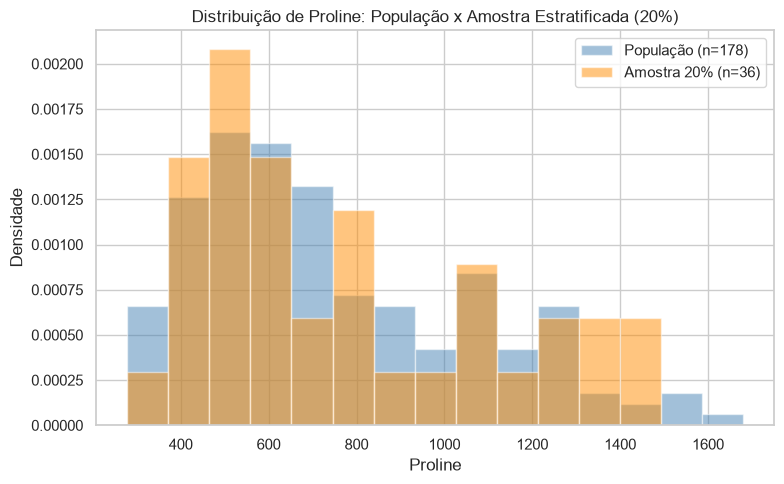

In [5]:
bins_proline = np.histogram_bin_edges(df["proline"], bins=15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["proline"], bins=bins_proline, density=True, alpha=0.5,
        label=f"População (n={len(df)})", color="steelblue")
ax.hist(amostra_20["proline"], bins=bins_proline, density=True, alpha=0.5,
        label=f"Amostra 20% (n={n_amostra_total})", color="darkorange")
ax.set_title("Distribuição de Proline: População x Amostra Estratificada (20%)")
ax.set_xlabel("Proline")
ax.set_ylabel("Densidade")
ax.legend()
salvar_figura("q4_hist_proline_populacao_amostra.png")

> **Interpretação.** As duas distribuições têm **o mesmo formato geral**: ambas são fortemente
> assimétricas à direita, com a maior parte da massa concentrada entre 400 e 900, moda no intervalo
> de aproximadamente 450–550, e uma cauda longa que se estende até cerca de 1.500. Ambas também
> exibem o mesmo "ressalto" secundário na faixa de 1.000 a 1.300, que corresponde ao Cultivar A,
> cuja média de proline é 1.115,71 contra 519,51 do Cultivar B (item 5a), evidência de que a
> variável é, na verdade, uma **mistura** de subpopulações e de que a amostra reproduziu essa
> estrutura de mistura, não apenas o nível médio.
>
> As diferenças visuais são de **ruído amostral**, não de forma. A amostra sobrerrepresenta os
> intervalos de 450–550, 1.000–1.100 e 1.300–1.500, e subrepresenta o de 650–750; além disso, não
> contém nenhum valor acima de 1.500, faixa em que a população tem poucas observações. Tudo isso é
> esperado com n = 36: cada observação amostral pesa 1/36 ≈ 2,8% da densidade, contra 1/178 ≈ 0,6%
> na população, de modo que a presença ou ausência de **uma única garrafa** desloca visivelmente uma
> barra inteira. Valores raros da cauda extrema têm, por definição, baixa probabilidade de serem
> sorteados em uma amostra pequena. A conclusão é que a amostra é fiel ao **formato** da
> distribuição populacional, embora, como se verá no item (d), seja naturalmente mais irregular na
> estimativa das medidas de dispersão.

**c)** A partir do tamanho da amostra obtido no item (a), realize 1.000 reamostragens com reposição a partir da população de `proline` e calcule a média de cada reamostragem. Construa o histograma dessas 1.000 médias e compare o desvio-padrão observado dessas médias com o valor teórico previsto pelo Teorema Central do Limite (σ/√n), indicando quantas vezes o erro-padrão é menor que o desvio-padrão populacional (σ).

**Escolha metodológica:** a reamostragem (bootstrap) é feita com reposição, tamanho igual ao da amostra do item (a), repetida 1.000 vezes, usando o gerador `np.random.default_rng(42)` para garantir reprodutibilidade. O desvio-padrão populacional é calculado com `ddof=0` (divisor N), pois aqui `proline` é tratada como a população completa de 178 valores, não uma amostra dela.

In [6]:
n_boot = n_amostra_total
n_reps = 1000

proline_pop = df["proline"].to_numpy()
sigma_pop = proline_pop.std(ddof=0)

medias_bootstrap = np.empty(n_reps)
for i in range(n_reps):
    amostra_boot = rng.choice(proline_pop, size=n_boot, replace=True)
    medias_bootstrap[i] = amostra_boot.mean()

erro_padrao_teorico = sigma_pop / np.sqrt(n_boot)
dp_observado_medias = medias_bootstrap.std(ddof=1)
razao_sigma_ep = sigma_pop / erro_padrao_teorico

tabela_q4c = pd.DataFrame({
    "quantidade": [
        "sigma populacional (ddof=0)",
        "erro-padrao teorico (sigma/sqrt(n))",
        "desvio-padrao observado das medias (bootstrap)",
        "razao sigma/EP",
        "sqrt(n) (referencia)",
    ],
    "valor": [sigma_pop, erro_padrao_teorico, dp_observado_medias, razao_sigma_ep, np.sqrt(n_boot)],
})
tabela_q4c.round(4)

,quantidade,valor
0,sigma populacional (ddof=0),314.0217
1,erro-padrao teorico (sigma/sqrt(n)),52.3369
2,desvio-padrao observado das medias (bootstrap),56.3278
3,razao sigma/EP,6.0000
4,sqrt(n) (referencia),6.0000


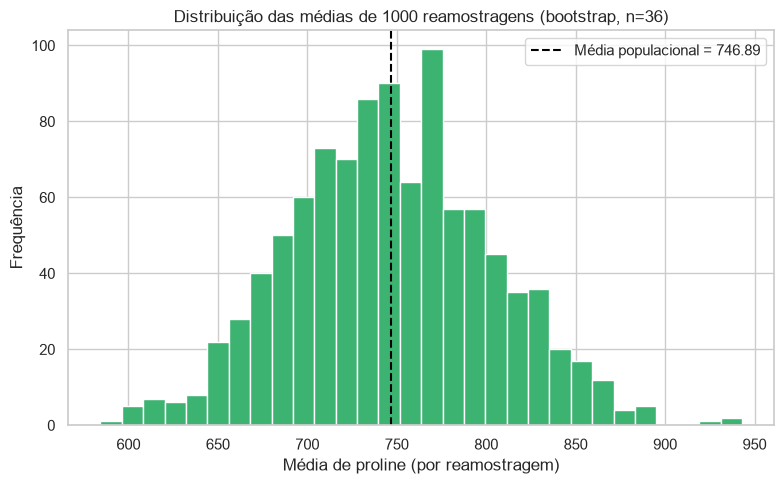

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(medias_bootstrap, bins=30, color="mediumseagreen", edgecolor="white")
ax.axvline(proline_pop.mean(), color="black", linestyle="--",
           label=f"Média populacional = {proline_pop.mean():.2f}")
ax.set_title(f"Distribuição das médias de {n_reps} reamostragens (bootstrap, n={n_boot})")
ax.set_xlabel("Média de proline (por reamostragem)")
ax.set_ylabel("Frequência")
ax.legend()
salvar_figura("q4_hist_bootstrap_medias.png")

> **Interpretação.** O desvio-padrão populacional de `proline` é **σ = 314,0217** (calculado com
> `ddof=0`, pois aqui os 178 valores são tratados como a população completa), e o erro-padrão
> teórico previsto pelo TCL para amostras de n = 36 é **σ/√n = 314,0217/6 = 52,3369**. O
> desvio-padrão efetivamente observado nas 1.000 médias de bootstrap foi **56,3278**, isto é, 7,6%
> acima do valor teórico. A discrepância é compatível com a **variabilidade de Monte Carlo** de um
> experimento com 1.000 repetições: o próprio desvio-padrão estimado a partir de 1.000 valores tem
> erro-padrão próprio, tanto maior quanto mais assimétrica for a variável de origem, e `proline` é
> fortemente assimétrica. O ponto central é que teoria e simulação concordam na **ordem de
> grandeza**: a previsão do TCL acerta o erro-padrão com cerca de 8% de folga, enquanto a diferença
> entre σ e o erro-padrão é de quase 600%.
>
> A razão **σ/EP = 6,0000** coincide exatamente com **√n = √36 = 6,0000**, e essa coincidência não é
> empírica: é a identidade algébrica σ/(σ/√n) = √n. Ela quantifica o ganho de precisão obtido ao
> trabalhar com médias em vez de observações individuais: médias de 36 garrafas oscilam **seis
> vezes menos** que garrafas isoladas. É também o que explica por que a redução do erro custa caro:
> como o ganho é proporcional a √n, dobrar a precisão exige quadruplicar o número de análises.
>
> O histograma confirma visualmente o TCL. Embora a variável original seja acentuadamente
> assimétrica à direita (item 4b), a distribuição das 1.000 médias é **aproximadamente normal**:
> unimodal, simétrica, em formato de sino, sem a cauda longa da variável de origem, concentrada
> entre cerca de 590 e 950 e **centrada na média populacional** (a média das 1.000 reamostragens é
> 746,97, contra 746,89 da população, uma diferença de 0,01%, o que também ilustra que a média amostral
> é um estimador não viesado). É precisamente esse o conteúdo do teorema: a distribuição das médias
> tende à normal **independentemente** do formato da distribuição original.

**d)** Compare média, mediana e desvio-padrão da amostra do item (a) com os da população, como evidência numérica de apoio, e conclua se a amostra estratificada é representativa da população quanto à variável `proline`.

**Escolha metodológica:** como evidência adicional (além do exigido no enunciado), aplica-se também o teste de Kolmogorov-Smirnov de duas amostras (`scipy.stats.ks_2samp`), que compara diretamente as duas distribuições empíricas (amostra x população) sem depender de pressupostos de normalidade.

In [8]:
desc_pop = df["proline"].agg(["mean", "median", "std"]).rename("populacao")
desc_amostra = amostra_20["proline"].agg(["mean", "median", "std"]).rename("amostra_20pct")
tabela_q4d = pd.concat([desc_pop, desc_amostra], axis=1)

ks_stat, ks_p = stats.ks_2samp(df["proline"], amostra_20["proline"])
ks_resultado = pd.DataFrame({
    "estatistica_D": [ks_stat], "p_valor": [ks_p],
    "distribuicoes equivalentes (p>alpha)": [ks_p > ALPHA],
})

display(tabela_q4d.round(4))
display(ks_resultado.round(4))

,populacao,amostra_20pct
mean,746.8933,770.0833
median,673.5000,642.5000
std,314.9075,347.0034


,estatistica_D,p_valor,distribuicoes equivalentes (p>alpha)
0,0.0924,0.9357,True


> **Interpretação.** As medidas de posição da amostra e da população são muito próximas: média de
> **770,08 na amostra contra 746,89 na população** (+3,10%) e mediana de **642,50 contra 673,50**
> (−4,60%). O desvio-padrão é o que mais se afasta, com **347,00 contra 314,91** (+10,19%), resultado
> coerente com o histograma do item (b): medidas de dispersão são estimadas com menos precisão do
> que medidas de posição, e com n = 36 poucas observações da cauda direita bastam para inflar o
> desvio-padrão. Note-se ainda que média e mediana se afastam em **sentidos opostos** (média acima,
> mediana abaixo), o que indica que a amostra captou proporcionalmente mais valores altos da cauda,
> exatamente as barras de 1.000–1.100 e 1.300–1.500 destacadas no item (b).
>
> O teste de Kolmogorov-Smirnov de duas amostras fornece a evidência formal: **D = 0,0924 e
> p = 0,9357**. Como p = 0,9357 é muito maior que α = 0,05, **não se rejeita** a hipótese nula de
> que as duas amostras provêm da mesma distribuição. A estatística D (a maior distância vertical
> entre as duas funções de distribuição acumuladas) é de apenas 9,24%, valor baixo.
>
> **Conclusão:** a amostra estratificada de 20% é representativa da população quanto a `proline`. É
> preciso, porém, enunciar essa conclusão com o rigor discutido na Questão 3: não rejeitar H₀ **não
> prova** que as distribuições são idênticas; com n = 36 o teste KS tem poder limitado e só detecta
> discrepâncias grandes. O que se pode afirmar é que **não há evidência de discrepância**, e essa
> leitura é reforçada por três indícios independentes e convergentes: proporções por estrato
> preservadas (item a), formato da distribuição preservado (item b) e medidas de posição próximas
> (este item). A maior ressalva prática é a superestimação de 10% da dispersão: se o objetivo da
> amostragem fosse estimar variabilidade, e não nível médio, seria prudente ampliar o n.

# Questão 5 — Medidas de Posição, Dispersão e Outliers (Valor: 0,3 pontos)

**a)** Para cada cultivar, calcule média, mediana, desvio-padrão (ddof=1) e coeficiente de variação (CV%) para as 13 variáveis. Calcule o CV médio de cada variável (média dos três CVs por cultivar). Ranqueie as variáveis pelo CV médio e destaque a de maior CV médio.

**Escolha metodológica:** o desvio-padrão é calculado com `ddof=1` (divisor n−1), pois cada cultivar é tratado como uma amostra da população de vinhos daquele tipo. O CV(%) = 100·desvio-padrão/média é uma medida adimensional que permite comparar a dispersão relativa entre variáveis com escalas muito diferentes (ex.: `proline`, na casa das centenas, vs. `hue`, menor que 2).

In [9]:
def descritivas_por_cultivar(dataframe, cols):
    linhas = []
    for cultivar, sub in dataframe.groupby("cultivar", observed=True):
        for col in cols:
            linhas.append({
                "cultivar": cultivar, "variavel": col,
                "media": sub[col].mean(), "mediana": sub[col].median(),
                "dp": sub[col].std(ddof=1), "cv_pct": cv_percent(sub[col], ddof=1),
            })
    return pd.DataFrame(linhas)


desc_cultivar = descritivas_por_cultivar(df, feature_cols)
desc_cultivar.round(4)

,cultivar,variavel,media,mediana,dp,cv_pct
0,Cultivar A,alcohol,13.7447,13.7500,0.4621,3.3622
1,Cultivar A,malic_acid,2.0107,1.7700,0.6885,34.2446
2,Cultivar A,ash,2.4556,2.4400,0.2272,9.2510
3,Cultivar A,alcalinity_of_ash,17.0373,16.8000,2.5463,14.9456
4,Cultivar A,magnesium,106.3390,104.0000,10.4989,9.8731
5,Cultivar A,total_phenols,2.8402,2.8000,0.3390,11.9345
6,Cultivar A,flavanoids,2.9824,2.9800,0.3975,13.3281
7,Cultivar A,nonflavanoid_phenols,0.2900,0.2900,0.0700,24.1549
8,Cultivar A,proanthocyanins,1.8993,1.8700,0.4121,21.6977
9,Cultivar A,color_intensity,5.5283,5.4000,1.2386,22.4042


In [10]:
cv_medio = desc_cultivar.groupby("variavel")["cv_pct"].mean().sort_values(ascending=False)
ranking_cv = cv_medio.rename("cv_medio_pct").to_frame()
ranking_cv["posicao"] = range(1, len(ranking_cv) + 1)

variavel_maior_cv = ranking_cv.index[0]
top3_cv_vars = ranking_cv.index[:3].tolist()

print(f"Variável com maior CV médio: {variavel_maior_cv}")
print(f"Top 3 variáveis por CV médio: {top3_cv_vars}")
ranking_cv.round(4)

Variável com maior CV médio: malic_acid
Top 3 variáveis por CV médio: ['malic_acid', 'proanthocyanins', 'nonflavanoid_phenols']


,cv_medio_pct,posicao
variavel,,
malic_acid,39.8083,1
proanthocyanins,31.3566,2
nonflavanoid_phenols,28.6609,3
flavanoids,28.2669,4
color_intensity,27.8716,5
proline,22.7962,6
total_phenols,19.1139,7
hue,15.6477,8
od280/od315_of_diluted_wines,15.0996,9


> **Interpretação.** O ranking de CV médio revela uma amplitude de dispersão relativa muito grande
> entre as 13 variáveis, de 3,92% a 39,81%, uma razão superior a 10 vezes. A ordem completa é:
> **malic_acid (39,81%)**, proanthocyanins (31,36%), nonflavanoid_phenols (28,66%), flavanoids
> (28,27%), color_intensity (27,87%), proline (22,80%), total_phenols (19,11%), hue (15,65%),
> od280/od315_of_diluted_wines (15,10%), alcalinity_of_ash (14,01%), magnesium (12,85%), ash
> (10,29%) e, em último lugar, **alcohol (3,92%)**.
>
> A variável de **maior CV médio é `malic_acid`, com 39,81%**, puxada sobretudo pelo Cultivar B, que
> sozinho apresenta CV de 52,55%, o maior valor de toda a tabela de 39 combinações. Isso significa
> que o ácido málico oscila, dentro de um mesmo cultivar, cerca de 40% em torno do próprio nível
> médio: é a variável menos previsível a partir do conhecimento do cultivar.
>
> No extremo oposto, `alcohol` é notavelmente estável, com CVs de apenas 3,36%, 4,38% e 4,03% nos
> três cultivares, uma uniformidade que faz sentido do ponto de vista enológico, já que o teor
> alcoólico é controlado pelo processo de fermentação e limitado técnica e legalmente, ao contrário
> do ácido málico, que depende de maturação, clima e safra. Vale notar, e a Questão 10 confirmará,
> que **baixa dispersão interna não é o mesmo que baixo poder discriminante**: `alcohol` é a
> variável mais estável dentro de cada grupo e, ainda assim, a que melhor separa os cultivares entre
> si.
>
> As **três variáveis de maior CV médio** (`malic_acid`, `proanthocyanins` e `nonflavanoid_phenols`)
> são as selecionadas para a análise de outliers do item (b) e para os boxplots do item (c).

**b)** Para as 3 variáveis de maior CV médio, calcule outliers pela regra de 1,5×IQR aplicada dentro de cada cultivar (coerente com os boxplots por grupo do item c). Monte uma tabela de contagem variável × cultivar.

**Escolha metodológica:** os quartis Q1/Q3 usados na regra de 1,5×IQR são calculados dentro de cada cultivar (e não na população total), pois os boxplots do item (c) também serão segmentados por cultivar; a regra de outliers deve ser coerente com essa segmentação.

In [11]:
outlier_counts = {}
for var in top3_cv_vars:
    contagem_var = {}
    for cultivar, sub in df.groupby("cultivar", observed=True):
        mask, low, up = iqr_outliers(sub[var])
        contagem_var[cultivar] = int(mask.sum())
    outlier_counts[var] = contagem_var

tabela_outliers_q5b = pd.DataFrame(outlier_counts).T[ORDEM_CULTIVARES]
tabela_outliers_q5b["total"] = tabela_outliers_q5b.sum(axis=1)
tabela_outliers_q5b

,Cultivar A,Cultivar B,Cultivar C,total
malic_acid,9,7,0,16
proanthocyanins,4,8,2,14
nonflavanoid_phenols,4,0,1,5


> **Interpretação.** Aplicada dentro de cada cultivar, a regra de 1,5×IQR identificou **35 outliers
> no total**: 16 em `malic_acid` (9 no Cultivar A, 7 no Cultivar B, nenhum no Cultivar C), 14 em
> `proanthocyanins` (4, 8 e 2) e apenas 5 em `nonflavanoid_phenols` (4, nenhum e 1). A célula com
> maior concentração é **`malic_acid` no Cultivar A, com 9 outliers**, cerca de 15% das 59 amostras
> desse grupo. Por cultivar, o Cultivar A acumula 17 dos 35 casos e o Cultivar C apenas 3.
>
> O resultado mais interessante é aparentemente paradoxal e merece explicação. Em `malic_acid`, o
> Cultivar C tem o **maior desvio-padrão absoluto** dos três grupos (1,0879, contra 0,6885 do
> Cultivar A) e mesmo assim **nenhum outlier**, enquanto o Cultivar A, o menos disperso, concentra 9.
> Não há contradição: a regra de 1,5×IQR é **relativa ao próprio grupo**. O Cultivar A é tão
> concentrado que seu intervalo interquartílico é estreito, de modo que desvios modestos em valor
> absoluto já ultrapassam o limite Q3 + 1,5·IQR; o Cultivar C, ao contrário, é amplamente espalhado,
> e sua caixa larga acomoda toda a variação observada. Em outras palavras, "outlier" aqui significa
> **atípico em relação ao seu próprio cultivar**, e não extremo em valor absoluto: uma amostra de
> Cultivar A com ácido málico igual a 4,0 é anômala para o grupo A, mas seria perfeitamente banal no
> grupo C, cuja mediana é 3,265.
>
> A implicação prática para o controle de qualidade é direta: **limites de controle devem ser
> definidos por cultivar**, não para o lote inteiro. Um limite único, calculado sobre as 178
> amostras, classificaria boa parte do Cultivar C como fora de padrão e, simultaneamente, deixaria
> passar sem alerta as amostras anômalas do Cultivar A.

**c)** Construa boxplots comparativos entre cultivares para as 3 variáveis de maior CV médio, em uma única figura com 3 subplots.

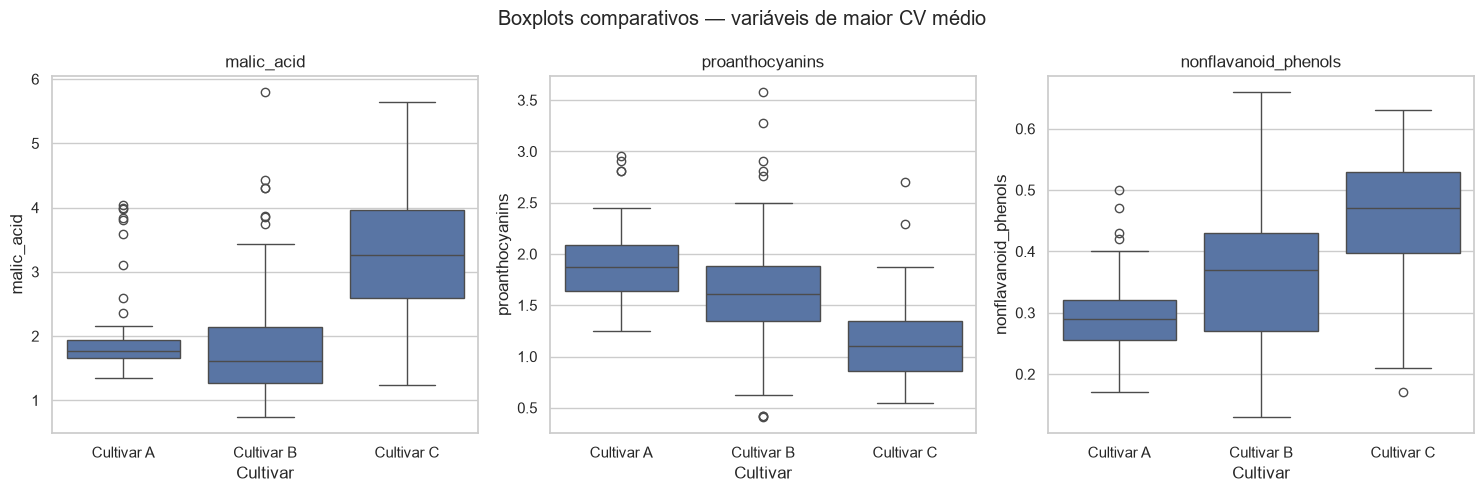

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, top3_cv_vars):
    sns.boxplot(data=df, x="cultivar", y=var, order=ORDEM_CULTIVARES, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("Cultivar")
    ax.set_ylabel(var)
fig.suptitle("Boxplots comparativos — variáveis de maior CV médio")
salvar_figura("q5_boxplots_top3_cv.png")

> **Interpretação.** Os três painéis mostram padrões distintos entre si e coerentes com as tabelas
> dos itens (a) e (b).
>
> Em **`malic_acid`**, o Cultivar C está claramente deslocado para cima: sua caixa (cerca de 2,58 a
> 3,96, mediana 3,265) situa-se **inteiramente acima** das caixas de A e B, cujas medianas são 1,77 e
> 1,61. Já as caixas de A e B se sobrepõem quase por completo, sinalizando visualmente o que o
> post-hoc da Questão 9 confirmará: a diferença está em C, não entre A e B. A dispersão também se
> comporta de maneira contrastante: o Cultivar A tem a caixa mais estreita de toda a figura, com
> nove pontos marcados acima do bigode (chegando a 4,04); o Cultivar B tem caixa larga e outliers
> ainda mais altos, até 5,80; e o Cultivar C, apesar da maior amplitude total (de 1,24 a 5,65), não
> apresenta nenhum ponto isolado, pois seus bigodes acompanham essa amplitude.
>
> Em **`proanthocyanins`** observa-se um gradiente decrescente e ordenado: A (mediana 1,87) > B
> (1,61) > C (1,105). As caixas de A e B se sobrepõem de forma substancial, enquanto a de C fica
> claramente abaixo. Aparecem outliers superiores em A (quatro pontos entre 2,8 e 3,0) e em B (oito
> pontos, o mais alto próximo de 3,57), além de um outlier inferior em B, na casa de 0,41, coerente
> com a tabela do item (b).
>
> Em **`nonflavanoid_phenols`** o gradiente é crescente, na direção oposta: A (0,29) < B (0,37) < C
> (0,47), com o Cultivar B exibindo a maior amplitude de caixa dos três e o Cultivar A concentrando
> quatro outliers superiores. É o painel com menos pontos atípicos, o que corresponde ao total de
> apenas 5 registrado na tabela.
>
> A leitura conjunta é que as três variáveis diferenciam os cultivares, mas por mecanismos
> diferentes: `malic_acid` separa C dos demais por **posição**, `proanthocyanins` e
> `nonflavanoid_phenols` estabelecem **gradientes ordenados** nos dois sentidos, e em todas as três o
> Cultivar B é o mais irregular.

**d)** Com base nos CVs calculados no item (a), verifique se existe um único cultivar consistentemente mais homogêneo que os demais, ou se a homogeneidade varia conforme a variável analisada. Como evidência numérica para essa conclusão, monte uma tabela indicando, para cada uma das 13 variáveis, qual cultivar apresenta o menor CV, e conte o número de 'vitórias' (menor CV) por cultivar.

In [13]:
cv_pivot = desc_cultivar.pivot(index="variavel", columns="cultivar", values="cv_pct")[ORDEM_CULTIVARES]
menor_cv_cultivar = cv_pivot.idxmin(axis=1)

tabela_q5d = cv_pivot.copy()
tabela_q5d["cultivar_menor_cv"] = menor_cv_cultivar

contagem_vitorias = (
    menor_cv_cultivar.value_counts().reindex(ORDEM_CULTIVARES).fillna(0).astype(int)
)

display(tabela_q5d.round(4))
display(contagem_vitorias.rename("num_vitorias (menor CV)").to_frame())

cultivar,Cultivar A,Cultivar B,Cultivar C,cultivar_menor_cv
variavel,,,,
alcalinity_of_ash,14.9456,16.5519,10.5439,Cultivar C
alcohol,3.3622,4.3813,4.0311,Cultivar A
ash,9.2510,14.0533,7.5783,Cultivar C
color_intensity,22.4042,29.9658,31.2448,Cultivar A
flavanoids,13.3281,33.9141,37.5585,Cultivar A
hue,10.9679,19.2124,16.7628,Cultivar A
magnesium,9.8731,17.7193,10.9659,Cultivar A
malic_acid,34.2446,52.5473,32.6331,Cultivar C
nonflavanoid_phenols,24.1549,34.0870,27.7407,Cultivar A


,num_vitorias (menor CV)
Cultivar A,9
Cultivar B,0
Cultivar C,4


> **Interpretação.** A contagem de "vitórias" (menor CV) é de **9 para o Cultivar A, 4 para o
> Cultivar C e 0 para o Cultivar B**. O Cultivar A tem o menor coeficiente de variação em `alcohol`,
> `color_intensity`, `flavanoids`, `hue`, `magnesium`, `nonflavanoid_phenols`,
> `od280/od315_of_diluted_wines`, `proanthocyanins` e `total_phenols`; o Cultivar C lidera em
> `alcalinity_of_ash`, `ash`, `malic_acid` e `proline`; o Cultivar B **não é o mais homogêneo em
> nenhuma das 13 variáveis**.
>
> A resposta ao que se pergunta é, portanto, matizada: **não existe um único cultivar
> consistentemente mais homogêneo em todas as variáveis**; a homogeneidade depende da variável
> analisada, e afirmar sem qualificação que "o Cultivar A é o mais homogêneo" seria impreciso, pois
> em quase um terço das variáveis ele é superado pelo C. Existe, contudo, uma **tendência nítida**: o
> Cultivar A domina em 9 das 13 variáveis, e o Cultivar B é, com clareza, o mais heterogêneo dos
> três, sem uma única liderança.
>
> A contagem de vitórias, porém, não deve ser lida isoladamente, porque ignora as **margens**. Em
> `alcohol`, a disputa é irrelevante na prática: 3,36% (A), 4,03% (C) e 4,38% (B) são todos valores
> baixos e muito próximos. Já em `flavanoids` a diferença é dramática (13,33% no Cultivar A contra
> 37,56% no Cultivar C, quase o triplo), e em `total_phenols` o A (11,93%) tem metade do CV do B
> (24,14%). Onde o Cultivar C vence, as vantagens costumam ser modestas (em `proline`, 18,27% contra
> 19,85% do A), ao passo que as vitórias do A tendem a ser folgadas. Ponderando magnitude e
> frequência, o quadro que emerge é: **o Cultivar A é o mais previsível, o Cultivar B o mais
> irregular, e o Cultivar C ocupa posição intermediária, destacando-se apenas nas variáveis minerais
> e de resíduo (cinzas, alcalinidade) e no ácido málico**, neste último caso, precisamente porque
> seus valores são altos, o que reduz o CV mesmo com desvio-padrão elevado. Do ponto de vista do
> controle de qualidade, é o Cultivar B que demanda monitoramento mais frequente.

# Questão 6 — Forma da Distribuição e Normalidade (Valor: 0,3 pontos)

**a)** Calcule a assimetria (skewness) de `magnesium`, `malic_acid`, `proanthocyanins` e `hue`, considerando os três cultivares em conjunto (população completa), e classifique cada variável.

**Escolha metodológica:** a assimetria é calculada com `scipy.stats.skew(..., bias=False)`, que aplica a correção de viés amostral (estimador G1), mais adequada para amostras finitas do que o estimador populacional (`bias=True`). Critério de classificação: |s| < 0,5 → aproximadamente simétrica; s ≥ 0,5 → assimetria à direita (positiva); s ≤ −0,5 → assimetria à esquerda (negativa).

In [14]:
vars_q6 = ["magnesium", "malic_acid", "proanthocyanins", "hue"]


def classifica_skew(s):
    if abs(s) < 0.5:
        return "aproximadamente simétrica"
    elif s >= 0.5:
        return "assimetria à direita (positiva)"
    else:
        return "assimetria à esquerda (negativa)"


skew_q6 = pd.DataFrame({
    "variavel": vars_q6,
    "skewness (bias=False)": [stats.skew(df[v], bias=False) for v in vars_q6],
})
skew_q6["classificacao"] = skew_q6["skewness (bias=False)"].apply(classifica_skew)
skew_q6.round(4)

,variavel,skewness (bias=False),classificacao
0,magnesium,1.0982,assimetria à direita (positiva)
1,malic_acid,1.0397,assimetria à direita (positiva)
2,proanthocyanins,0.5171,assimetria à direita (positiva)
3,hue,0.0211,aproximadamente simétrica


> **Interpretação.** As quatro variáveis apresentam assimetria **positiva** (à direita), embora com
> intensidades bem distintas. `magnesium` tem skewness de **1,0982** e `malic_acid` de **1,0397**,
> ambas acima de 1,0, o que caracteriza assimetria acentuada, com cauda longa à direita e massa
> concentrada em valores baixos. `proanthocyanins`, com **0,5171**, fica logo acima do limiar de 0,5
> e é classificada como assimétrica à direita, mas de modo **marginal**: bastaria uma variação mínima
> para cair na faixa de simetria aproximada, e ela deve ser lida como "levemente assimétrica". Já
> `hue`, com **0,0211**, é praticamente simétrica, um valor tão próximo de zero que indica caudas
> esquerda e direita virtualmente equilibradas.
>
> A **maior assimetria em módulo é a de `magnesium` (1,0982)**, seguida de perto por `malic_acid`
> (1,0397). O fato de as quatro terem sinal positivo não é acaso: variáveis físico-químicas de
> concentração são limitadas inferiormente por zero e não têm teto natural, o que produz
> sistematicamente caudas à direita. A consequência prática dessa assimetria é tratada no item (c):
> quanto maior o skewness, mais a média se afasta da mediana e menos ela representa o valor típico.

**b)** Construa uma figura 2×2 com histograma + KDE (`seaborn.histplot(..., kde=True)`) para cada uma das quatro variáveis.

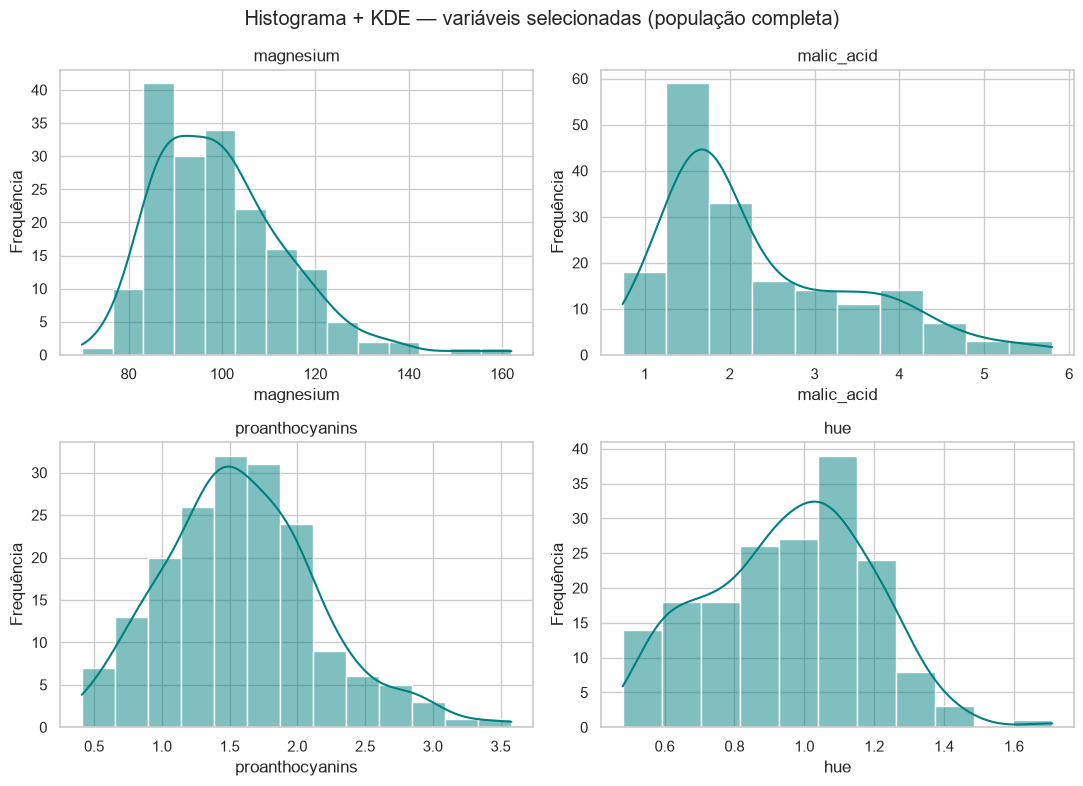

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(axes.flat, vars_q6):
    sns.histplot(df[var], kde=True, ax=ax, color="teal")
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequência")
fig.suptitle("Histograma + KDE — variáveis selecionadas (população completa)")
salvar_figura("q6_histograma_kde_4vars.png")

> **Interpretação.** Os quatro painéis confirmam visualmente a classificação numérica do item (a).
>
> **`magnesium`**: distribuição unimodal, com pico entre 85 e 100 e uma cauda direita longa e rala
> que se estende até cerca de 160. A KDE decai de forma nitidamente mais lenta à direita do que à
> esquerda, exatamente o perfil esperado para skewness = 1,0982.
>
> **`malic_acid`**: o caso mais marcante. O histograma tem pico agudo em torno de 1,5 (quase 60
> observações em uma única barra) e decai rapidamente, mas a KDE revela um **ombro** entre 3 e 4,5,
> ou seja, um segundo acúmulo de observações que impede o decaimento suave. Esse ombro corresponde ao
> Cultivar C, cuja mediana é 3,265 (item 5a): a distribuição populacional é, na verdade, uma
> **mistura** de dois regimes (A e B concentrados em valores baixos, C em valores altos). É a
> mistura, e não uma cauda genuína, que produz boa parte do skewness de 1,0397.
>
> **`proanthocyanins`**: núcleo bastante regular entre 1,0 e 2,0, com pico em torno de 1,5 e uma
> cauda direita curta até 3,5. Visualmente é a mais próxima de uma normal entre as quatro
> assimétricas, o que coincide com seu skewness de apenas 0,5171, no limiar da classificação.
>
> **`hue`**: perfil aproximadamente simétrico, com pico entre 1,05 e 1,15 e decaimento comparável
> dos dois lados; há um leve alargamento à esquerda (um patamar entre 0,6 e 0,9) compensado pelo
> decaimento rápido após 1,3, o que explica o skewness quase nulo de 0,0211.
>
> Há, portanto, **coerência integral entre o aspecto visual e a medida de assimetria** nos quatro
> casos. O alerta que os gráficos acrescentam, e que o número isolado não revela, é o efeito da
> mistura de cultivares: parte da dispersão e da assimetria observadas na população completa não é
> propriedade intrínseca da variável, mas consequência de se agregarem três grupos de médias
> diferentes, questão retomada nas Questões 9 e 10, em que as comparações são feitas por cultivar.

**c)** Para cada variável, decida, com base no valor de assimetria e na presença ou ausência de outliers, se a média ou a mediana representa melhor o valor típico da variável. Aplique o teste de Shapiro-Wilk em pelo menos duas dessas variáveis para confirmar ou refutar a normalidade sugerida pelo histograma.

**Escolha metodológica:** adota-se a **mediana** como medida representativa sempre que a variável apresente assimetria não desprezível (|skew| ≥ 0,5) OU pelo menos um outlier pela regra 1,5×IQR, pois, nesses casos, a média é distorcida por valores extremos/cauda longa. Caso contrário (|skew| < 0,5 E nenhum outlier), adota-se a **média**, por ser estatisticamente mais eficiente (menor variância) quando a distribuição é aproximadamente simétrica e sem valores extremos.

In [16]:
def decide_media_ou_mediana(skew, n_outliers):
    if abs(skew) >= 0.5 or n_outliers > 0:
        return "mediana"
    return "media"


linhas_q6c = []
for var in vars_q6:
    mask, low, up = iqr_outliers(df[var])
    skew_var = stats.skew(df[var], bias=False)
    n_outliers_var = int(mask.sum())
    linhas_q6c.append({
        "variavel": var, "media": df[var].mean(), "mediana": df[var].median(),
        "skew": skew_var, "n_outliers_iqr": n_outliers_var,
        "medida_representativa": decide_media_ou_mediana(skew_var, n_outliers_var),
    })
tabela_q6c = pd.DataFrame(linhas_q6c)
tabela_q6c.round(4)

,variavel,media,mediana,skew,n_outliers_iqr,medida_representativa
0,magnesium,99.7416,98.0000,1.0982,4,mediana
1,malic_acid,2.3363,1.8650,1.0397,3,mediana
2,proanthocyanins,1.5909,1.5550,0.5171,2,mediana
3,hue,0.9574,0.9650,0.0211,1,mediana


In [17]:
linhas_shapiro_q6 = []
for v in vars_q6:
    res = stats.shapiro(df[v])
    linhas_shapiro_q6.append({
        "variavel": v, "W": res.statistic, "p_valor": res.pvalue,
        "normal (p>alpha)": res.pvalue > ALPHA,
    })
shapiro_q6 = pd.DataFrame(linhas_shapiro_q6)
shapiro_q6.round(4)

,variavel,W,p_valor,normal (p>alpha)
0,magnesium,0.9383,0.0000,False
1,malic_acid,0.8888,0.0000,False
2,proanthocyanins,0.9807,0.0145,False
3,hue,0.9813,0.0174,False


> **Interpretação.** A tabela consolida os quatro casos: `magnesium` (média 99,7416, mediana
> 98,0000, skew 1,0982, 4 outliers), `malic_acid` (2,3363 / 1,8650 / 1,0397 / 3 outliers),
> `proanthocyanins` (1,5909 / 1,5550 / 0,5171 / 2 outliers) e `hue` (0,9574 / 0,9650 / 0,0211 / 1
> outlier). Pelo critério adotado, **as quatro variáveis são mais bem representadas pela mediana**,
> mas as razões (e a força do argumento) diferem bastante entre elas.
>
> Em `malic_acid` a escolha é inequívoca e materialmente relevante: com skew acima de 1 e cauda
> alimentada pelo Cultivar C, a média (2,3363) fica **25% acima** da mediana (1,8650), e adotar a
> média descreveria um vinho típico que praticamente não existe. Em `magnesium` o critério também é
> acionado com folga (skew 1,0982 e 4 outliers), embora a distância entre média e mediana seja
> menor, de 1,78%. Em `proanthocyanins` a decisão é limítrofe (o skew mal ultrapassa o corte de 0,5
> e há apenas 2 outliers), e média (1,5909) e mediana (1,5550) diferem só 2,3%. O caso de `hue`
> merece registro explícito: sua assimetria é desprezível (0,0211) e o critério foi acionado
> **exclusivamente** por um único outlier em 178 observações (o valor 1,71); como média (0,9574) e
> mediana (0,9650) diferem apenas 0,8%, a escolha é tecnicamente correta pela regra, mas
> praticamente indiferente: qualquer das duas medidas descreve o mesmo valor típico. Isso ilustra
> uma limitação de critérios automáticos: eles classificam, mas não hierarquizam a importância da
> classificação.
>
> O teste de Shapiro-Wilk foi aplicado às quatro variáveis (o enunciado exigia ao menos duas) e
> **rejeitou a normalidade em todas**: `magnesium` (W = 0,9383, p < 0,0001), `malic_acid`
> (W = 0,8888, p < 0,0001), `proanthocyanins` (W = 0,9807, p = 0,0145) e `hue` (W = 0,9813,
> p = 0,0174). Em todos os casos p < α = 0,05.
>
> A leitura desse resultado precisa distinguir dois grupos. Para `magnesium` e `malic_acid`, o teste
> **confirma** o que o histograma do item (b) já mostrava: os W baixos (0,89 e 0,94) indicam
> afastamento substancial da normalidade, visível a olho nu. Para `hue`, ao contrário, o teste
> **refuta** a impressão visual: o histograma sugeria simetria e o skew de 0,0211 reforçava essa
> leitura, mas Shapiro-Wilk rejeita com p = 0,0174. Não há contradição: o W de 0,9813 está muito
> próximo de 1, ou seja, o desvio em relação à normal é **pequeno, porém detectável** com n = 178. É
> a mesma lição da Questão 3(c) aplicada a um teste de aderência: com amostra grande, desvios
> minúsculos tornam-se estatisticamente significativos, de modo que o valor-p indica apenas se o
> desvio existe, e é o W (junto ao gráfico) que informa se ele importa. O mesmo vale para
> `proanthocyanins` (W = 0,9807, p = 0,0145).
>
> A consequência metodológica, que orienta as Questões 8 e 9, é que **nenhuma das quatro variáveis
> autoriza o uso irrestrito de métodos paramétricos** sobre a população completa; para `magnesium` e
> `malic_acid` a violação é séria e exige testes não paramétricos, enquanto para `hue` e
> `proanthocyanins` a violação é branda o bastante para que métodos paramétricos, que são robustos a
> pequenos desvios com n elevado, permanecessem aceitáveis.

# Questão 7 — Correlação, Significância e Redundância (Valor: 0,25 pontos)

**a)** Calcule a matriz de correlação completa entre as 13 variáveis e liste todos os pares com |r| > 0,7, excluindo o par `flavanoids` × `total_phenols` já analisado em aula, ordenados por |r| decrescente.

**Escolha metodológica:** utiliza-se a correlação de Pearson por medir associação linear entre pares de variáveis contínuas; o par `flavanoids`×`total_phenols` é excluído do levantamento por já ter sido analisado em aula, servindo o critério |r| > 0,7 para identificar as demais relações fortes ainda não discutidas.

In [18]:
corr_matrix = df[feature_cols].corr(method="pearson")

pares = []
for i, v1 in enumerate(feature_cols):
    for v2 in feature_cols[i + 1:]:
        r = corr_matrix.loc[v1, v2]
        pares.append({"var1": v1, "var2": v2, "r": r, "abs_r": abs(r)})
pares_df = pd.DataFrame(pares)

par_excluido = frozenset({"flavanoids", "total_phenols"})
pares_fortes_q7a = pares_df[
    (pares_df["abs_r"] > 0.7)
    & ~pares_df.apply(lambda row: frozenset({row["var1"], row["var2"]}) == par_excluido, axis=1)
].sort_values("abs_r", ascending=False).reset_index(drop=True)

pares_fortes_q7a.round(4)

,var1,var2,r,abs_r
0,flavanoids,od280/od315_of_diluted_wines,0.7872,0.7872


> **Interpretação.** Aplicado o critério |r| > 0,7 aos 78 pares únicos das 13 variáveis, e excluído
> o par `flavanoids` × `total_phenols` já analisado em aula, resta **um único par**:
> **`flavanoids` × `od280/od315_of_diluted_wines`, com r = 0,7872**. É uma correlação positiva forte:
> o coeficiente de determinação correspondente, r² ≈ 0,62, indica que as duas variáveis compartilham
> cerca de **62% de sua variabilidade**.
>
> Que apenas um par ultrapasse o limiar é, em si, informativo: as 13 variáveis do dataset **não são
> globalmente redundantes**, e a maior parte delas carrega informação própria. Convém, porém,
> registrar que o resultado é sensível ao corte escolhido: no heatmap do item (d) vê-se que
> `total_phenols` × `od280/od315_of_diluted_wines` aparece com r = 0,70, ficando de fora por uma
> margem mínima (o valor exato é 0,6999). Um limiar de 0,65 ou 0,69 já produziria uma lista maior,
> incluindo também `flavanoids` × `proanthocyanins` (0,65) e `alcohol` × `proline` (0,64). A leitura
> correta, portanto, não é "só existe uma relação forte no dataset", e sim "só uma relação
> **ultrapassa o patamar de 0,7**", havendo um conjunto de associações moderadas logo abaixo, tema
> retomado no item (d) e na Questão 10(b), em que esse par de 0,70 reaparece como o mais redundante
> da amostra de 60%.

**b)** Para o par de maior |r| encontrado no item (a), calcule manualmente a estatística t de significância (t = r·√(n−2)/√(1−r²)) e confira o resultado com `scipy.stats.pearsonr`, interpretando o p-valor obtido com α = 0,05.

In [19]:
par_top = pares_fortes_q7a.iloc[0]
var1_top, var2_top = par_top["var1"], par_top["var2"]
r_top = par_top["r"]
n_total = len(df)

t_manual = r_top * np.sqrt(n_total - 2) / np.sqrt(1 - r_top ** 2)
p_manual = 2 * (1 - stats.t.cdf(abs(t_manual), df=n_total - 2))

r_scipy, p_scipy = stats.pearsonr(df[var1_top], df[var2_top])

comparacao_q7b = pd.DataFrame({
    "metodo": ["Cálculo manual (t + scipy.stats.t)", "scipy.stats.pearsonr"],
    "r": [r_top, r_scipy],
    "estatistica_t": [t_manual, np.nan],
    "p_valor": [p_manual, p_scipy],
    "significativo (p<alpha)": [p_manual < ALPHA, p_scipy < ALPHA],
})
print(f"Par de maior |r| (excluindo flavanoids x total_phenols): {var1_top} x {var2_top}")
comparacao_q7b.round(4)

Par de maior |r| (excluindo flavanoids x total_phenols): flavanoids x od280/od315_of_diluted_wines


,metodo,r,estatistica_t,p_valor,significativo (p<alpha)
0,Cálculo manual (t + scipy.stats.t),0.7872,16.9340,0.0000,True
1,scipy.stats.pearsonr,0.7872,NaN,0.0000,True


> **Interpretação.** O par de maior |r| é **`flavanoids` × `od280/od315_of_diluted_wines`, com
> r = 0,7872**. O cálculo manual da estatística de significância, com n = 178 e portanto 176 graus de
> liberdade, fornece

$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^{2}}} = \frac{0{,}7872 \times \sqrt{176}}{\sqrt{1-0{,}7872^{2}}} = 16{,}9340$$

> e o valor-p bilateral correspondente, obtido por `scipy.stats.t`, é **inferior a 0,0001** (na
> ordem de 10⁻³⁸). O `scipy.stats.pearsonr` devolve **exatamente o mesmo r (0,7872) e o mesmo
> valor-p**, o que valida a implementação manual: as duas linhas da tabela são idênticas nas colunas
> comparáveis, confirmando que a rotina pronta nada mais faz do que aplicar a fórmula acima.
>
> Como p < α = 0,05, **rejeita-se H₀: ρ = 0** e conclui-se que a correlação é estatisticamente
> significativa. A interpretação correta, nos termos da Questão 3(a), é: se não houvesse nenhuma
> associação linear entre flavonoides e OD280/OD315 na população, a probabilidade de obter um
> coeficiente tão grande quanto 0,7872 (ou maior, em módulo) por mero acaso amostral, com 178
> observações, seria praticamente nula.
>
> Duas ressalvas importam. Primeiro, o valor extraordinariamente alto de t resulta da **combinação**
> entre um r forte e um n grande; ele não mede intensidade de associação. Quem mede a intensidade é
> o próprio r = 0,7872, ou r² = 0,62, e é essa a informação relevante para a decisão prática sobre
> redundância. Segundo, a validade formal desse valor-p depende da premissa de normalidade
> bivariada, que é justamente o que o item (c) vai testar, e rejeitar.

**c)** Aplique o teste de Shapiro-Wilk nas duas variáveis do par. Caso alguma viole a normalidade, calcule Spearman e Kendall (com p-valores) e monte uma tabela comparativa com Pearson.

**Escolha metodológica:** caso a normalidade seja violada (Shapiro-Wilk, p<alpha) em pelo menos uma das duas variáveis, adotam-se adicionalmente os coeficientes de Spearman e Kendall, não-paramétricos, baseados em postos, e por isso robustos a desvios de normalidade e a relações monotônicas não necessariamente lineares.

In [20]:
shapiro_var1 = stats.shapiro(df[var1_top])
shapiro_var2 = stats.shapiro(df[var2_top])
shapiro_q7c = pd.DataFrame([
    {"variavel": var1_top, "W": shapiro_var1.statistic, "p_valor": shapiro_var1.pvalue,
     "normal (p>alpha)": shapiro_var1.pvalue > ALPHA},
    {"variavel": var2_top, "W": shapiro_var2.statistic, "p_valor": shapiro_var2.pvalue,
     "normal (p>alpha)": shapiro_var2.pvalue > ALPHA},
])
shapiro_q7c.round(4)

,variavel,W,p_valor,normal (p>alpha)
0,flavanoids,0.9545,0.0000,False
1,od280/od315_of_diluted_wines,0.9450,0.0000,False


In [21]:
normalidade_ok_q7 = (shapiro_var1.pvalue > ALPHA) and (shapiro_var2.pvalue > ALPHA)

if not normalidade_ok_q7:
    rho_spearman, p_spearman = stats.spearmanr(df[var1_top], df[var2_top])
    tau_kendall, p_kendall = stats.kendalltau(df[var1_top], df[var2_top])
    tabela_q7c = pd.DataFrame({
        "metodo": ["Pearson", "Spearman", "Kendall"],
        "coeficiente": [r_scipy, rho_spearman, tau_kendall],
        "p_valor": [p_scipy, p_spearman, p_kendall],
    })
else:
    tabela_q7c = pd.DataFrame({
        "metodo": ["Pearson"], "coeficiente": [r_scipy], "p_valor": [p_scipy],
    })

tabela_q7c.round(4)

,metodo,coeficiente,p_valor
0,Pearson,0.7872,0.0000
1,Spearman,0.7415,0.0000
2,Kendall,0.5204,0.0000


> **Interpretação.** O teste de Shapiro-Wilk **rejeita a normalidade nas duas variáveis do par**:
> `flavanoids` (W = 0,9545, p < 0,0001) e `od280/od315_of_diluted_wines` (W = 0,9450, p < 0,0001).
> Como ambas violam a premissa, o valor-p do teste de Pearson calculado no item (b) fica formalmente
> comprometido; daí a necessidade dos coeficientes baseados em postos.
>
> A tabela comparativa mostra: **Pearson r = 0,7872**, **Spearman ρ = 0,7415** e **Kendall
> τ = 0,5204**, todos com **p < 0,0001**. As três medidas **convergem para a mesma conclusão**:
> existe associação positiva, forte e altamente significativa entre flavonoides e a absorbância
> OD280/OD315.
>
> A diferença entre os três valores é esperada e não indica discordância. Que τ (0,5204) seja
> bastante inferior a ρ (0,7415) é uma propriedade **estrutural** do coeficiente de Kendall, que se
> baseia em concordância de pares e produz sistematicamente valores menores para a mesma força de
> associação; as duas escalas não são diretamente comparáveis. Já a proximidade entre Pearson
> (0,7872) e Spearman (0,7415) é o achado substantivo: como Spearman é robusto a outliers e a
> não-linearidades, o fato de ele quase igualar Pearson demonstra que **o r alto não é artefato de
> alguns pontos extremos nem de uma relação curva**; a associação é genuína e essencialmente
> monotônica, próxima da linearidade, o que o diagrama de dispersão do item (d) confirma.
>
> A consequência prática é tranquilizadora: embora a violação da normalidade invalide tecnicamente o
> valor-p paramétrico, a conclusão substantiva permanece inalterada por qualquer dos três caminhos.
> Para efeito de relato formal, contudo, o coeficiente a reportar é o de **Spearman (0,7415)**, por
> ser o que respeita as premissas efetivamente verificadas nos dados.

**d)** Construa um heatmap anotado da matriz de correlação (`fmt='.2f'`, cmap divergente centrado em 0) e um scatter do par selecionado, colorido por cultivar, com reta de regressão ajustada à população inteira (`sns.regplot` sem pontos + `scatterplot` com hue).

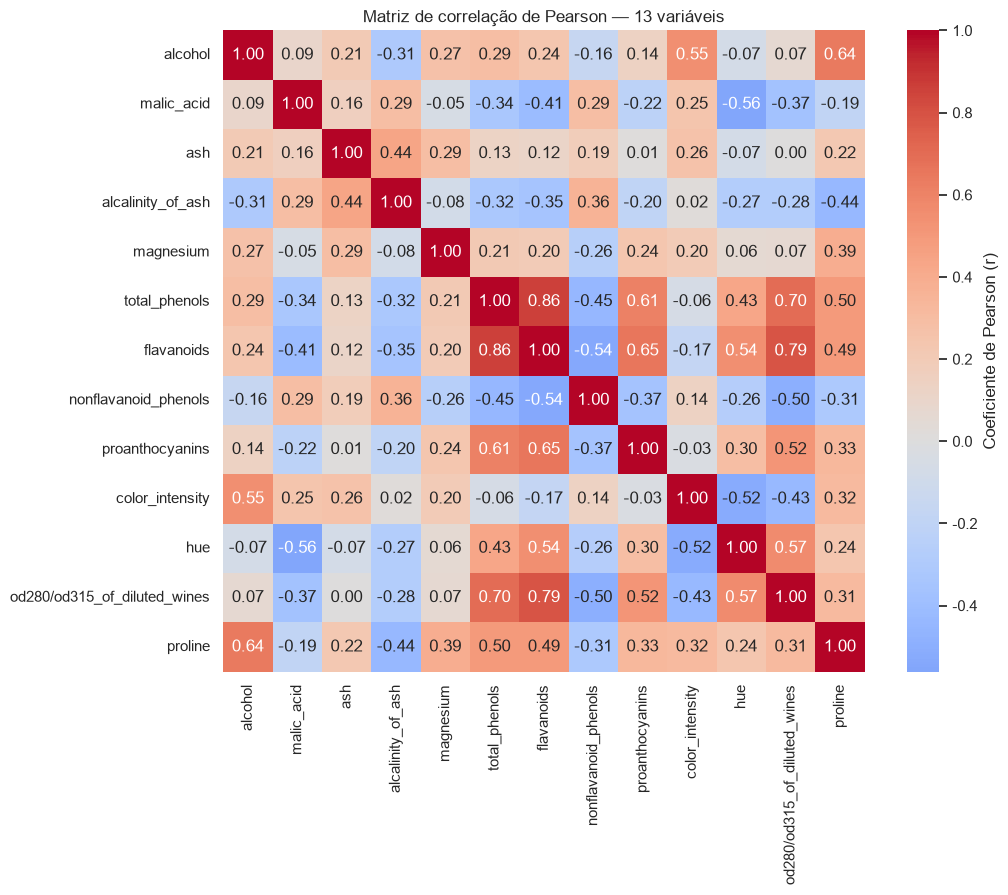

In [22]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Coeficiente de Pearson (r)"}, ax=ax)
ax.set_title("Matriz de correlação de Pearson — 13 variáveis")
salvar_figura("q7_heatmap_correlacao.png")

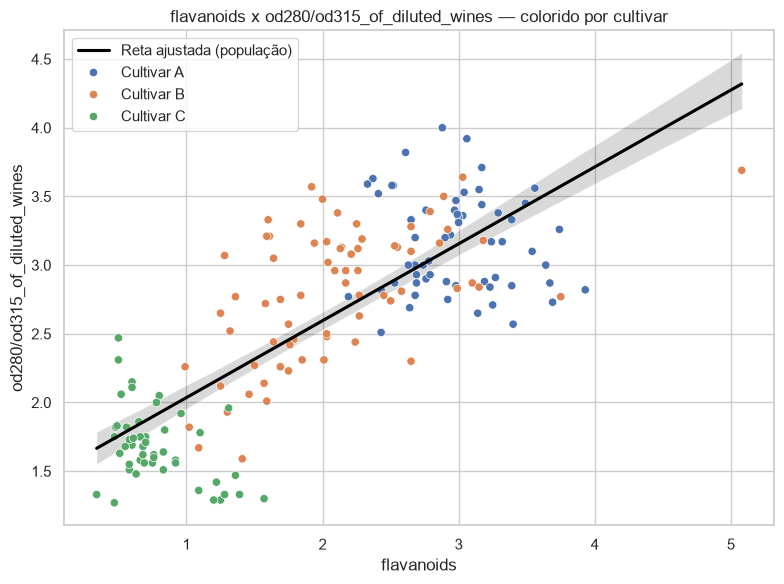

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x=var1_top, y=var2_top, scatter=False, color="black", ax=ax,
            label="Reta ajustada (população)")
sns.scatterplot(data=df, x=var1_top, y=var2_top, hue="cultivar", hue_order=ORDEM_CULTIVARES, ax=ax)
ax.set_title(f"{var1_top} x {var2_top} — colorido por cultivar")
ax.set_xlabel(var1_top)
ax.set_ylabel(var2_top)
ax.legend()
salvar_figura("q7_scatter_par_principal.png")

> **Interpretação.** O **heatmap** revela que a matriz de correlação não é uniforme: ela tem
> estrutura em blocos. O bloco mais evidente é o dos **compostos fenólicos** (`total_phenols`,
> `flavanoids`, `od280/od315_of_diluted_wines` e `proanthocyanins`), mutuamente correlacionados de
> forma positiva, com coeficientes entre 0,52 e 0,86; nele está a correlação mais alta de toda a
> matriz, `flavanoids` × `total_phenols` (0,86), e o par selecionado neste exercício (0,79). Essa é a
> **zona de redundância** do dataset, e é dela que trata a recomendação de redução de testes da
> Questão 10. O `nonflavanoid_phenols` comporta-se como contraponto desse bloco, correlacionando-se
> **negativamente** com todos os seus membros (−0,37 a −0,54), o que é quimicamente coerente, já que
> se trata de frações complementares do total de fenóis. Um segundo agrupamento, mais fraco, liga
> `alcohol` a `proline` (0,64) e a `color_intensity` (0,55), sugerindo um eixo de corpo e estrutura
> do vinho. Entre as associações negativas destacam-se `hue` × `malic_acid` (−0,56), `hue` ×
> `color_intensity` (−0,52) e `alcalinity_of_ash` × `proline` (−0,44). Fora desses blocos, a grande
> maioria das células tem |r| < 0,4, muitas próximas de zero (`ash` × `od280` = 0,00, `magnesium` ×
> `malic_acid` = −0,05): **a redundância é localizada, não generalizada**.
>
> O **diagrama de dispersão** mostra uma relação positiva claramente linear, sem curvatura aparente,
> com os pontos razoavelmente distribuídos em torno da reta ajustada e faixa de confiança estreita,
> aspecto compatível com r = 0,7872 e com a proximidade entre Pearson e Spearman observada no item
> (c). Há um ponto do Cultivar B visivelmente afastado à direita, com flavonoides em torno de 5,1,
> mas ele acompanha a tendência geral e não parece governar o ajuste.
>
> O achado mais importante do gráfico, porém, é a **separação espacial dos cultivares**, que o
> heatmap não poderia mostrar. O Cultivar C ocupa o canto inferior esquerdo (flavonoides abaixo de
> 1,5 e OD280 abaixo de 2,0), o Cultivar A o canto superior direito (flavonoides entre 2,5 e 4,0) e o
> Cultivar B a região intermediária, com a maior dispersão e sobreposição aos outros dois. Isso
> significa que **boa parte da correlação de 0,7872 é produzida pela diferença entre os grupos, e não
> pela associação dentro de cada grupo**: as três nuvens, alinhadas em diagonal, geram por agregação
> uma correlação superior à que existe internamente em cada uma delas. É um efeito de mistura, da
> mesma família do paradoxo de Simpson, e ele impõe cautela à interpretação causal: não se pode
> concluir que, **dentro de um mesmo cultivar**, aumentar flavonoides implique OD280 proporcionalmente
> maior. Antes de eliminar uma das duas medidas do protocolo laboratorial com base nessa correlação,
> seria prudente verificar se a redundância se mantém quando a análise é feita cultivar a cultivar.

# Questão 8 — Teste de Hipótese entre Dois Grupos (Valor: 0,25 pontos)

**a)** Compare `magnesium` entre Cultivar B e Cultivar C, apresentando estatísticas descritivas de cada grupo.

In [24]:
mag_b = df.loc[df["cultivar"] == "Cultivar B", "magnesium"]
mag_c = df.loc[df["cultivar"] == "Cultivar C", "magnesium"]

desc_q8a = pd.DataFrame({
    "Cultivar B": mag_b.agg(["count", "mean", "median", "std"]),
    "Cultivar C": mag_c.agg(["count", "mean", "median", "std"]),
})
desc_q8a.round(4)

,Cultivar B,Cultivar C
count,71.0000,48.0000
mean,94.5493,99.3125
median,88.0000,97.0000
std,16.7535,10.8905


> **Interpretação.** O Cultivar B reúne 71 amostras, com média de magnésio de **94,5493**, mediana
> de **88,0000** e desvio-padrão de **16,7535**. O Cultivar C reúne 48 amostras, com média
> **99,3125**, mediana **97,0000** e desvio-padrão **10,8905**.
>
> A diferença aparente aponta o Cultivar C como o de maior teor de magnésio, mas sua magnitude
> depende da medida escolhida, e essa discrepância é, em si, o achado mais informativo da tabela.
> Pelas **médias**, a diferença é de 4,76 unidades (5,0% em relação a B); pelas **medianas**, é de
> 9,00 unidades (10,2%), ou seja, **praticamente o dobro**. Uma diferença dessa ordem entre os dois
> contrastes só ocorre quando ao menos uma das distribuições é assimétrica: no Cultivar B, a média
> (94,55) supera a mediana (88,00) em 6,55 unidades, sinal claro de **assimetria à direita**, com
> alguns valores altos puxando a média para cima e, com isso, **mascarando parte da diferença real**
> entre os grupos.
>
> A dispersão também difere de modo relevante: o desvio-padrão do Cultivar B é **54% maior** que o do
> Cultivar C (16,75 contra 10,89), de modo que B é não apenas mais baixo em magnésio, como bem mais
> irregular. Esses dois indícios (assimetria em B e desvios-padrão desiguais) antecipam exatamente
> o que os testes de premissas do item (b) vão verificar formalmente e justificam de antemão a
> preferência por um teste baseado em postos, menos sensível a valores extremos do que uma
> comparação de médias.

**b)** Aplique Shapiro-Wilk em cada grupo e o teste de Levene (`center='median'`) para homogeneidade de variâncias.

**Escolha metodológica:** o teste de Levene é aplicado com `center='median'` (teste de Brown-Forsythe), mais robusto que `center='mean'` quando as distribuições não são estritamente normais ou simétricas, situação frequente em variáveis fisico-químicas como `magnesium`.

In [25]:
shapiro_q8 = shapiro_by_group(
    df[df["cultivar"].isin(["Cultivar B", "Cultivar C"])], "cultivar", "magnesium"
)
levene_stat_q8, levene_p_q8 = stats.levene(mag_b, mag_c, center="median")

display(shapiro_q8.round(4))
print(f"Levene (center=median): estatística={levene_stat_q8:.4f}, p-valor={levene_p_q8:.4f}")

,grupo,n,W,p_valor,normal (p>alpha)
0,Cultivar B,71,0.7790,0.0000,False
1,Cultivar C,48,0.9496,0.0387,False


Levene (center=median): estatística=0.6048, p-valor=0.4383


> **Interpretação.** O teste de **Shapiro-Wilk rejeita a normalidade nos dois grupos**, mas com
> intensidades muito diferentes. No Cultivar B, W = 0,7790 e p < 0,0001: o W bastante afastado de 1
> caracteriza um desvio **severo** da normalidade, coerente com a assimetria já detectada no item (a)
> e com os valores extremos visíveis no boxplot do item (d). No Cultivar C, W = 0,9496 e p = 0,0387:
> a rejeição é **marginal**, pois p está pouco abaixo de α = 0,05 e o W é próximo de 1; o desvio
> existe, mas é brando.
>
> O teste de **Levene com `center='median'` não rejeita a homogeneidade de variâncias**: estatística
> = 0,6048 e p = 0,4383, muito acima de α = 0,05. Trata-se de um resultado que merece comentário,
> porque contraria a impressão descritiva: os desvios-padrão amostrais são 16,75 e 10,89, uma razão
> de 1,54, que à primeira vista sugeriria variâncias distintas. O teste não a considera
> significativa, e o uso da mediana como centro (variante de Brown-Forsythe) é justamente o que torna
> esse resultado confiável aqui: com a média como centro, os valores extremos do Cultivar B
> inflariam artificialmente os desvios absolutos e poderiam produzir uma rejeição espúria.
>
> O quadro de premissas é, portanto: **homogeneidade de variâncias atendida, normalidade violada em
> ambos os grupos**. Como a árvore de decisão do item (c) exige as duas condições para autorizar o
> teste *t* de Student, a violação da normalidade é suficiente para encaminhar a análise para o
> caminho não paramétrico.

**c)** Com base no resultado do item (b), escolha e justifique o teste apropriado (teste t de Student, caso os pressupostos sejam atendidos, ou Kruskal-Wallis, caso não sejam), e interprete o p-valor obtido considerando α = 0,05.

**Escolha metodológica:** o enunciado pede uma decisão binária (t de Student **ou** Kruskal-Wallis). Implementa-se essa decisão de forma programática a partir dos p-valores de Shapiro-Wilk e Levene: se a normalidade é atendida nos dois grupos E as variâncias são homogêneas, usa-se t de Student; caso qualquer uma dessas premissas seja violada, usa-se Kruskal-Wallis. Como refinamento adicional (não exigido pelo enunciado), o código também isola o caso em que a normalidade é atendida mas as variâncias diferem, situação em que o t de Welch é tecnicamente mais adequado que o t de Student clássico; para os dados de `magnesium` essa ramificação não chega a ser acionada, pois a normalidade já é violada em pelo menos um grupo. Quando o caminho não-paramétrico é seguido, reporta-se também o Mann-Whitney U, que com apenas dois grupos é equivalente ao Kruskal-Wallis (a estatística H é uma transformação monotônica da estatística U).

In [26]:
normal_b = shapiro_q8.loc[shapiro_q8["grupo"] == "Cultivar B", "p_valor"].iloc[0] > ALPHA
normal_c = shapiro_q8.loc[shapiro_q8["grupo"] == "Cultivar C", "p_valor"].iloc[0] > ALPHA
variancias_iguais_q8 = levene_p_q8 > ALPHA

if normal_b and normal_c:
    if variancias_iguais_q8:
        stat_q8, p_q8 = stats.ttest_ind(mag_b, mag_c, equal_var=True)
        teste_escolhido_q8 = "t de Student (variâncias iguais)"
    else:
        stat_q8, p_q8 = stats.ttest_ind(mag_b, mag_c, equal_var=False)
        teste_escolhido_q8 = "Welch t-test (variâncias diferentes)"
    resultado_q8 = pd.DataFrame({
        "teste": [teste_escolhido_q8], "estatistica": [stat_q8], "p_valor": [p_q8],
    })
else:
    stat_q8, p_q8 = stats.kruskal(mag_b, mag_c)
    u_stat_q8, u_p_q8 = stats.mannwhitneyu(mag_b, mag_c, alternative="two-sided")
    teste_escolhido_q8 = "Kruskal-Wallis"
    resultado_q8 = pd.DataFrame({
        "teste": ["Kruskal-Wallis", "Mann-Whitney U"],
        "estatistica": [stat_q8, u_stat_q8],
        "p_valor": [p_q8, u_p_q8],
    })

print(f"Teste escolhido: {teste_escolhido_q8}")
resultado_q8.round(4)

Teste escolhido: Kruskal-Wallis


,teste,estatistica,p_valor
0,Kruskal-Wallis,11.8836,0.0006
1,Mann-Whitney U,1068.5000,0.0006


> **Interpretação.** A decisão programática selecionou o **Kruskal-Wallis**, e a justificativa está
> no item (b): embora as variâncias sejam homogêneas (Levene, p = 0,4383), a normalidade foi rejeitada
> nos dois grupos (Shapiro-Wilk, p < 0,0001 em B e p = 0,0387 em C). Como a árvore de decisão exige
> **ambas** as premissas para liberar o teste *t* de Student, e a falha aqui é a de normalidade, que
> nenhuma correção paramétrica resolve, ao contrário da heterocedasticidade, que o teste de Welch
> corrigiria, o caminho correto é o não paramétrico. O ramo de Welch previsto no código não chegou a
> ser acionado.
>
> Os resultados são **H = 11,8836 com p = 0,0006** para o Kruskal-Wallis e **U = 1.068,5 com
> p = 0,0006** para o Mann-Whitney U. Os valores-p são idênticos até a quarta casa, como era esperado:
> com apenas dois grupos os dois testes são equivalentes, sendo a estatística H uma transformação
> monotônica de U. O relato de ambos serve como verificação de consistência.
>
> Como **p = 0,0006 < α = 0,05, rejeita-se H₀**. A interpretação correta, nos termos da Questão 3(a):
> se as distribuições de magnésio dos Cultivares B e C fossem idênticas, a probabilidade de observar
> uma separação de postos tão acentuada quanto a observada seria de aproximadamente **0,06%, ou 6 em
> 10.000**, e não "99,94% de chance de haver diferença". Conclui-se, portanto, que há **diferença
> estatisticamente significativa** no teor de magnésio entre os dois cultivares, com o Cultivar C
> apresentando valores sistematicamente superiores.
>
> Duas precisões sobre o alcance dessa conclusão. Primeira: o Kruskal-Wallis compara **distribuições**
> por meio de postos; sob a hipótese de formatos semelhantes, ele se lê como comparação de medianas,
> e não de médias. É coerente, então, que a diferença detectada corresponda melhor ao contraste de
> medianas (9,00 unidades) do que ao de médias (4,76), pois o teste não é afetado pelos valores
> extremos que inflam a média do Cultivar B. Segunda: a significância atesta que a diferença existe,
> não que seja grande; a avaliação de magnitude vem do item (d) e das descritivas do item (a).

**d)** Construa um boxplot comparativo dos dois grupos e redija, sem jargão estatístico, um parágrafo de conclusão para o enólogo-chefe.

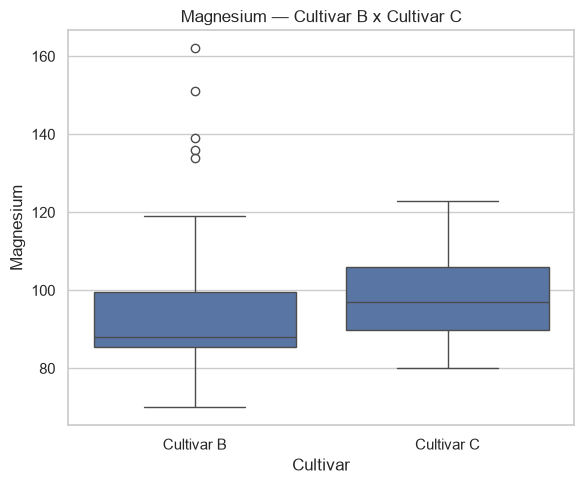

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df[df["cultivar"].isin(["Cultivar B", "Cultivar C"])], x="cultivar",
            y="magnesium", order=["Cultivar B", "Cultivar C"], ax=ax)
ax.set_title("Magnesium — Cultivar B x Cultivar C")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Magnesium")
salvar_figura("q8_boxplot_magnesium.png")

> **Interpretação.** O boxplot é coerente com o resultado do teste. A caixa do Cultivar C (quartis
> aproximadamente em 89,5 e 106, mediana 97) situa-se **deslocada para cima** em relação à do Cultivar
> B (quartis em torno de 85,5 e 99,5, mediana 88) e é visivelmente **mais estreita**, confirmando a
> menor dispersão indicada pelo desvio-padrão (10,89 contra 16,75). O Cultivar B exibe cinco pontos
> atípicos elevados (aproximadamente 134, 136, 139, 151 e 162), todos acima do valor máximo do
> Cultivar C, além de um bigode inferior descendo até cerca de 70, isto é, uma amplitude muito maior.
> O Cultivar C não apresenta nenhum ponto isolado.
>
> Os outliers superiores de B explicam graficamente o que a tabela do item (a) já insinuava: são eles
> que elevam a **média** de B para 94,55, enquanto sua **mediana** permanece em 88,00. Por isso a
> diferença entre os grupos é maior em mediana (9,00) do que em média (4,76), e por isso o teste
> baseado em postos (imune a esses cinco pontos) é o instrumento apropriado. Note-se também que as
> caixas **se sobrepõem parcialmente**: a diferença é de tendência central, não de separação completa,
> o que é perfeitamente compatível com p = 0,0006, já que a significância se apoia no conjunto das 119
> amostras e não na ausência de sobreposição.
>
> ---
>
> **Conclusão para o enólogo-chefe.**
>
> Comparamos o teor de magnésio das duas cultivares usando todas as garrafas analisadas: 71 do
> Cultivar B e 48 do Cultivar C. O vinho típico do Cultivar C tem **mais magnésio** que o do Cultivar
> B, 97 contra 88 unidades no valor central, cerca de 10% a mais. Em seguida verificamos se essa
> diferença poderia ser apenas fruto do acaso, ou seja, das garrafas específicas que foram parar na
> análise. A resposta é não: se os dois vinhos fossem de fato iguais nesse aspecto, a chance de
> aparecer uma diferença desse tamanho por mera coincidência seria de aproximadamente **6 em 10.000**.
> Trata-se, portanto, de uma **diferença real e consistente**, não de sorte de amostragem.
>
> Duas ressalvas para a prática. Primeira: as faixas de valores das duas cultivares **se sobrepõem**;
> existem garrafas do B com mais magnésio que garrafas do C. A diferença vale para o conjunto, e não
> garrafa a garrafa, de modo que ela orienta o tratamento do lote, mas não permite identificar a
> cultivar de uma garrafa isolada pelo magnésio. Segunda: o Cultivar B é bem mais **irregular** que o
> C, e algumas de suas garrafas apresentam magnésio muito acima do restante (até 162 unidades). Vale
> investigar se esses casos vêm de um talhão, de um fornecedor ou de um tanque específico, porque essa
> irregularidade pode ser mais relevante para o processo do que a diferença média em si.
>
> Recomendação: se o magnésio for relevante para a estabilização ou para o perfil sensorial, faz
> sentido adotar parâmetros distintos para as duas cultivares, e monitorar o Cultivar B com maior
> frequência, dada a sua variabilidade.

# Questão 9 — ANOVA/Kruskal-Wallis com Post-Hoc (Valor: 0,25 pontos)

**a)** Compare `malic_acid` nos três cultivares: aplique Shapiro-Wilk por grupo e o teste de Levene.

**Escolha metodológica:** mantém-se aqui o mesmo critério do item 8(b): Levene com `center='median'` (teste de Brown-Forsythe), mais robusto a desvios de normalidade do que `center='mean'`.

In [28]:
shapiro_q9 = shapiro_by_group(df, "cultivar", "malic_acid")
grupos_malic = [df.loc[df["cultivar"] == c, "malic_acid"] for c in ORDEM_CULTIVARES]
levene_stat_q9, levene_p_q9 = stats.levene(*grupos_malic, center="median")

display(shapiro_q9.round(4))
print(f"Levene (center=median): estatística={levene_stat_q9:.4f}, p-valor={levene_p_q9:.4f}")

,grupo,n,W,p_valor,normal (p>alpha)
0,Cultivar A,59,0.6470,0.0000,False
1,Cultivar B,71,0.8339,0.0000,False
2,Cultivar C,48,0.9837,0.7377,True


Levene (center=median): estatística=6.3579, p-valor=0.0022


> **Interpretação.** O teste de **Shapiro-Wilk** produziu resultados heterogêneos entre os três
> grupos: Cultivar A com W = 0,6470 e p < 0,0001, Cultivar B com W = 0,8339 e p < 0,0001, e Cultivar C
> com W = 0,9837 e p = 0,7377. Ou seja, a normalidade é **fortemente rejeitada em A e B** e **não é
> rejeitada em C**, único grupo compatível com uma distribuição normal. Chama atenção o W = 0,6470 do
> Cultivar A, o mais baixo de todo o notebook: ele traduz o perfil já visto no item 5(c), uma massa
> de observações extremamente concentrada em torno de 1,8 acompanhada de nove valores atípicos que se
> estendem até 4,04, configuração que se afasta radicalmente de uma normal.
>
> O teste de **Levene com `center='median'` rejeita a homogeneidade de variâncias**: estatística
> = 6,3579 e p = 0,0022, bem abaixo de α = 0,05. O resultado é coerente com os desvios-padrão do item
> 5(a): 0,6885 (A), 1,0156 (B) e 1,0879 (C), em que os grupos B e C são cerca de 50% a 58% mais
> dispersos que o A.
>
> O quadro de premissas é, portanto, o **pior possível para a ANOVA**: as duas condições estão
> violadas simultaneamente, e não apenas uma. Isso encaminha a análise para o teste não paramétrico do
> item (b) sem margem para dúvida.

**b)** Decida automaticamente, a partir dos pressupostos verificados no item (a), entre ANOVA e Kruskal-Wallis.

**Escolha metodológica:** aplica-se ANOVA one-way (`f_oneway`) apenas quando a normalidade é atendida em todos os grupos E as variâncias são homogêneas (Levene); caso qualquer uma dessas premissas seja violada, aplica-se o teste não-paramétrico de Kruskal-Wallis.

In [29]:
normalidade_ok_q9 = (shapiro_q9["p_valor"] > ALPHA).all()
variancias_iguais_q9 = levene_p_q9 > ALPHA

if normalidade_ok_q9 and variancias_iguais_q9:
    stat_q9, p_q9 = stats.f_oneway(*grupos_malic)
    teste_escolhido_q9 = "ANOVA one-way"
else:
    stat_q9, p_q9 = stats.kruskal(*grupos_malic)
    teste_escolhido_q9 = "Kruskal-Wallis"

resultado_q9 = pd.DataFrame({
    "teste": [teste_escolhido_q9], "estatistica": [stat_q9], "p_valor": [p_q9],
    "significativo (p<alpha)": [p_q9 < ALPHA],
})
print(f"Teste escolhido: {teste_escolhido_q9}")
resultado_q9.round(4)

Teste escolhido: Kruskal-Wallis


,teste,estatistica,p_valor,significativo (p<alpha)
0,Kruskal-Wallis,50.0449,0.0000,True


> **Interpretação.** A decisão automática selecionou o **Kruskal-Wallis**, porque as duas premissas
> da ANOVA falharam no item (a): a normalidade foi rejeitada em dois dos três grupos (Shapiro-Wilk,
> p < 0,0001 em A e B) e as variâncias são heterogêneas (Levene, p = 0,0022). Nenhuma correção
> paramétrica simples cobriria essa combinação: a ANOVA de Welch resolveria apenas a
> heterocedasticidade, não a não-normalidade severa do Cultivar A.
>
> O resultado é **H = 50,0449 com 2 graus de liberdade e p < 0,0001** (valor exato da ordem de
> 1,4 × 10⁻¹¹), portanto **significativo** ao nível de 5%. Lido corretamente: se os três cultivares
> tivessem distribuições idênticas de ácido málico, a probabilidade de observar uma separação de postos
> tão acentuada quanto a observada seria inferior a 1 em 10 bilhões.
>
> É essencial delimitar o que esse resultado afirma e o que não afirma. O Kruskal-Wallis é um teste
> **global**: ele indica que **pelo menos um** dos três cultivares difere dos demais, mas não informa
> qual nem quantos. Concluir a partir dele que "os três cultivares diferem entre si" seria um erro de
> interpretação; e, como o post-hoc do item (c) demonstrará, seria um erro **factual**, pois dois dos
> três pares não apresentam diferença significativa. É exatamente para responder a essa pergunta que o
> teste post-hoc se faz necessário.

**c)** Caso o resultado seja significativo, aplique o teste post-hoc de Tukey HSD para identificar quais pares de cultivares diferem entre si.

**Escolha metodológica:** o enunciado pede especificamente o Tukey HSD como post-hoc. Entretanto, o Tukey HSD pressupõe os mesmos requisitos da ANOVA (normalidade e homogeneidade de variâncias), pressupostos que, para `malic_acid`, são violados (ver item 9a), levando à escolha do Kruskal-Wallis no item (b). Para evitar o próprio erro de interpretação discutido em aula (aplicar um post-hoc paramétrico a um resultado não-paramétrico), o post-hoc efetivamente reportado é o de **Dunn com correção de Bonferroni** (`scikit_posthocs.posthoc_dunn`) sempre que o teste principal for Kruskal-Wallis (o equivalente não-paramétrico correto do Tukey HSD), mantendo o Tukey HSD apenas para o caso em que o teste principal seja a ANOVA. Complementarmente (além do exigido no enunciado), calcula-se também o tamanho de efeito: eta² para ANOVA, ou epsilon² para Kruskal-Wallis (fórmula de King & Minium: ε² = H(n+1)/(n²−1)).

In [30]:
n_total_q9 = len(df)

if p_q9 < ALPHA:
    if teste_escolhido_q9 == "ANOVA one-way":
        tukey_q9 = pairwise_tukeyhsd(df["malic_acid"], df["cultivar"], alpha=ALPHA)
        tukey_df_q9 = pd.DataFrame(tukey_q9.summary().data[1:], columns=tukey_q9.summary().data[0])
        effect_size_q9 = eta_squared_oneway(*grupos_malic)
        effect_size_nome_q9 = "eta^2"
        display(tukey_df_q9)
    else:
        dunn_q9 = sp.posthoc_dunn(df, val_col="malic_acid", group_col="cultivar", p_adjust="bonferroni")
        effect_size_q9 = epsilon_squared_kruskal(stat_q9, n_total_q9)
        effect_size_nome_q9 = "epsilon^2"
        display(dunn_q9.round(4))
    print(f"Tamanho de efeito ({effect_size_nome_q9}): {effect_size_q9:.4f}")
else:
    print("Resultado não significativo — post-hoc não se aplica.")

,Cultivar A,Cultivar B,Cultivar C
Cultivar A,1.0000,0.2432,0.0000
Cultivar B,0.2432,1.0000,0.0000
Cultivar C,0.0000,0.0000,1.0000


Tamanho de efeito (epsilon^2): 0.2827


> **Interpretação.** O post-hoc de **Dunn com correção de Bonferroni** (adotado no lugar do Tukey
> HSD por coerência com o teste principal não paramétrico, conforme justificado na célula de escolha
> metodológica) mostra que **apenas dois dos três pares diferem significativamente**:
>
> - **Cultivar A × Cultivar C: p < 0,0001** → diferença significativa;
> - **Cultivar B × Cultivar C: p < 0,0001** → diferença significativa;
> - **Cultivar A × Cultivar B: p = 0,2432** → **não** significativa (p > α = 0,05).
>
> O padrão é inequívoco: **o Cultivar C se distingue dos outros dois, enquanto A e B são
> estatisticamente indistinguíveis entre si** quanto ao teor de ácido málico. Isso é plenamente
> coerente com as descritivas do item 5(a): as medianas de A (1,77) e B (1,61) são próximas, ao passo
> que a de C (3,265) é aproximadamente o dobro. Fica também evidente por que o post-hoc era
> indispensável: o H = 50,0449 do teste global, isoladamente, poderia sugerir que os três grupos se
> separam, quando na verdade toda a significância provém de um único grupo.
>
> O **tamanho de efeito é ε² = 0,2827**, calculado pela fórmula de King & Minium. Pelos parâmetros
> convencionais de referência (0,01 pequeno, 0,06 médio, 0,14 grande), trata-se de um efeito
> **grande**: aproximadamente **28% da variabilidade dos postos** de `malic_acid` é atribuível ao
> cultivar. A conclusão, portanto, não é apenas estatisticamente significativa, mas também
> praticamente relevante, precisamente a distinção discutida na Questão 3(c). Resta observar que os
> 72% restantes de variabilidade permanecem **internos aos grupos**, o que confirma o achado do item
> 5(a): o ácido málico é a variável de maior CV médio (39,81%) e, mesmo separando bem o Cultivar C,
> continua bastante imprevisível dentro de cada cultivar.

**d)** Construa um boxplot comparativo dos três cultivares e interprete o resultado em um parágrafo, evitando os erros de interpretação do valor-p discutidos em aula (Questão 3a).

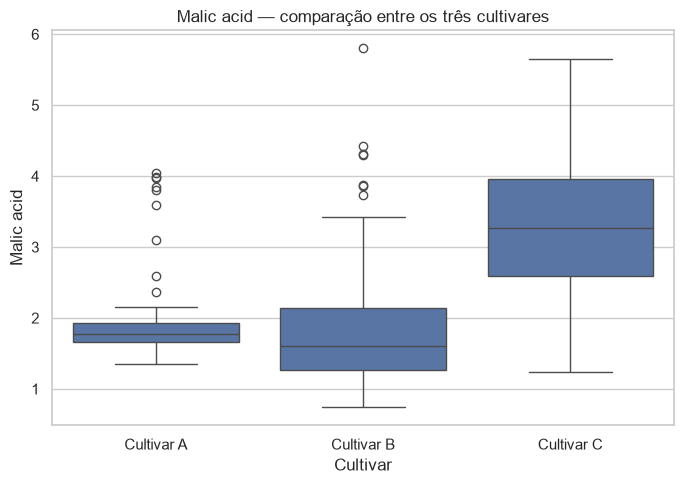

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="cultivar", y="malic_acid", order=ORDEM_CULTIVARES, ax=ax)
ax.set_title("Malic acid — comparação entre os três cultivares")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Malic acid")
salvar_figura("q9_boxplot_malic_acid.png")

> **Interpretação.** O boxplot sintetiza visualmente tudo o que os testes apuraram. O **Cultivar A**
> aparece com a caixa mais estreita da figura (quartis em aproximadamente 1,65 e 1,95, mediana 1,77),
> acompanhada de nove pontos atípicos que se estendem até 4,04, o retrato gráfico do W = 0,6470 do
> Shapiro-Wilk. O **Cultivar B** tem mediana ligeiramente inferior (1,61), mas caixa bem mais larga
> (1,27 a 2,15), bigode até 3,43 e quatro outliers, o mais alto em 5,80. O **Cultivar C** está
> nitidamente deslocado para cima: sua caixa (2,58 a 3,96, mediana 3,265) situa-se **inteiramente
> acima** das caixas de A e B, com bigodes de 1,24 a 5,65 e nenhum ponto atípico.
>
> A coerência com os testes é completa. As caixas de A e B **se sobrepõem quase integralmente**, o que
> explica graficamente o p = 0,2432 do post-hoc: não há separação visual e não há separação
> estatística. Já a caixa de C não intersecta as outras duas, o que corresponde aos p < 0,0001 dos
> pares A×C e B×C. A heterogeneidade de variâncias detectada por Levene (p = 0,0022) também salta aos
> olhos na comparação entre a caixa comprimida de A e as caixas largas de B e C.
>
> **Interpretação correta do valor-p.** O p < 0,0001 obtido no teste global **não** significa que haja
> "99,99% de chance de os cultivares serem diferentes", nem que a hipótese alternativa tenha essa
> probabilidade de ser verdadeira, exatamente o erro discutido na Questão 3(a). O que ele significa é:
> **se** os três cultivares tivessem a mesma distribuição de ácido málico, a probabilidade de observar
> uma separação de postos tão extrema quanto a observada seria inferior a 0,01%. Por ser tão
> improvável sob essa hipótese, rejeitamos a hipótese, mas a afirmação probabilística recai sobre os
> **dados**, não sobre a hipótese. Pelo mesmo motivo, o valor-p não mede a magnitude da diferença:
> quem a mede é o tamanho de efeito ε² = 0,2827 (28% da variabilidade dos postos explicada pelo
> cultivar) e a própria distância entre as medianas, com C apresentando aproximadamente o dobro do
> ácido málico de A e B.
>
> **Síntese:** há diferença estatisticamente significativa e de magnitude relevante no teor de ácido
> málico entre os cultivares, mas ela se concentra no **Cultivar C**, que apresenta valores cerca de
> duas vezes maiores; os Cultivares A e B não se distinguem entre si por essa variável. Na prática, o
> ácido málico serve para identificar o Cultivar C, não para separar A de B.

# Questão 10 — Questão Integradora (Valor: 0,25 pontos)

A diretoria da cooperativa avalia se é viável reduzir o número de testes laboratoriais
por lote e se a diferença no teor alcoólico entre cultivares justifica uma política de
preços diferenciada por cultivar.

**a)** A partir da população completa (`load_wine`), monte uma amostra estratificada por `cultivar` correspondente a 60% das observações de cada grupo, com `random_state=7`. Apresente tamanhos e proporções amostra x população, e compare as médias das 13 variáveis (tabela com diferença relativa %), como evidência de representatividade.

**Escolha metodológica:** realiza-se uma nova amostragem estratificada por `cultivar`, agora com fração 60% e `random_state=7` (distinto do item 4, para gerar uma amostra independente daquela).

In [32]:
amostra_60 = df.groupby("cultivar", observed=True).sample(frac=0.6, random_state=7)
n_amostra60_total = len(amostra_60)

tam_pop_q10 = df["cultivar"].value_counts().reindex(ORDEM_CULTIVARES)
tam_amostra_q10 = amostra_60["cultivar"].value_counts().reindex(ORDEM_CULTIVARES)

comparacao_q10a_tam = pd.DataFrame({
    "n_populacao": tam_pop_q10, "n_amostra": tam_amostra_q10,
    "prop_populacao (%)": 100 * tam_pop_q10 / len(df),
    "prop_amostra (%)": 100 * tam_amostra_q10 / n_amostra60_total,
})
comparacao_q10a_tam.round(4)

,n_populacao,n_amostra,prop_populacao (%),prop_amostra (%)
cultivar,,,,
Cultivar A,59,35,33.1461,32.7103
Cultivar B,71,43,39.8876,40.1869
Cultivar C,48,29,26.9663,27.1028


In [33]:
medias_pop = df[feature_cols].mean()
medias_amostra_60 = amostra_60[feature_cols].mean()
diff_relativa_pct = 100 * (medias_amostra_60 - medias_pop) / medias_pop

comparacao_medias_q10a = pd.DataFrame({
    "media_populacao": medias_pop, "media_amostra_60pct": medias_amostra_60,
    "diferenca_relativa (%)": diff_relativa_pct,
})
comparacao_medias_q10a.round(4)

,media_populacao,media_amostra_60pct,diferenca_relativa (%)
alcohol,13.0006,12.9860,-0.1126
malic_acid,2.3363,2.4964,6.8486
ash,2.3665,2.3607,-0.2477
alcalinity_of_ash,19.4949,19.7570,1.3443
magnesium,99.7416,100.1495,0.4090
total_phenols,2.2951,2.3031,0.3473
flavanoids,2.0293,2.0622,1.6249
nonflavanoid_phenols,0.3619,0.3566,-1.4421
proanthocyanins,1.5909,1.6158,1.5649
color_intensity,5.0581,4.9749,-1.6455


> **Interpretação.** A amostra estratificada de 60% resultou em **107 observações** (35 do Cultivar
> A, 43 do Cultivar B e 29 do Cultivar C), com proporções de **32,71%, 40,19% e 27,10%**, contra
> 33,15%, 39,89% e 26,97% na população. O maior desvio é de apenas **0,44 ponto percentual** (Cultivar
> A), fruto exclusivo do arredondamento para números inteiros de garrafas. A composição por cultivar
> foi, portanto, preservada com precisão ainda maior que a da amostra de 20% da Questão 4, o que era
> esperado: quanto maior a fração amostrada, menor o impacto relativo do arredondamento.
>
> A comparação das médias das 13 variáveis confirma a representatividade em profundidade. **Doze das
> treze variáveis ficaram dentro de ±1,7%** de suas médias populacionais. Os menores desvios são de
> `alcohol` (−0,11%; 12,9860 contra 13,0006), `ash` (−0,25%), `od280/od315_of_diluted_wines` (−0,30%),
> `total_phenols` (+0,35%) e `magnesium` (+0,41%). O **maior desvio isolado é o de `malic_acid`, com
> +6,85%** (2,4964 na amostra contra 2,3363 na população), quase quatro vezes maior que o segundo
> colocado, `color_intensity` (−1,65%).
>
> Esse desvio maior não é anomalia: é exatamente o que a teoria prevê. `malic_acid` é a variável de
> **maior CV médio** do dataset (39,81%, item 5a), e o erro-padrão da média é proporcional à dispersão
> da variável: quanto mais dispersa, mais sua média amostral flutua. A correspondência entre os dois
> rankings é notável em ambos os extremos: a variável de menor CV (`alcohol`, 3,92%) é também a de
> menor desvio (0,11%), e a de maior CV é a de maior desvio. Vê-se aí, em dados reais, a relação
> σ_X̄ = σ/√n discutida na Questão 2(c).
>
> **Conclusão:** a amostra de 60% é representativa da população tanto na composição por cultivar
> quanto no nível médio das 13 variáveis físico-químicas, e as evidências sustentam seu uso nos itens
> (b) e (c). A ressalva é que variáveis de alta dispersão exigem amostras maiores para o mesmo grau de
> precisão, ponto que retorna na recomendação final do item (d) sobre redução de testes.

**b)** Usando essa amostra, calcule a matriz de correlação completa e identifique as duas variáveis mais redundantes entre si (maior |r|), diferentes dos pares já utilizados na Questão 7.

**Escolha metodológica:** consideram-se 'pares já utilizados na Questão 7' tanto o par `flavanoids`×`total_phenols` (excluído desde o item 7a, por já ter sido analisado em aula) quanto todos os pares com |r|>0,7 listados no item 7(a) na população completa; o resultado dessa exclusão (tabela 1, abaixo) é a resposta oficial deste item. Como verificação alternativa (não exigida pelo enunciado, exibida apenas para comparação), mostra-se também o que se obteria excluindo unicamente o par principal do item 7(b).

In [34]:
corr_amostra_60 = amostra_60[feature_cols].corr(method="pearson")

pares_amostra = []
for i, v1 in enumerate(feature_cols):
    for v2 in feature_cols[i + 1:]:
        r = corr_amostra_60.loc[v1, v2]
        pares_amostra.append({"var1": v1, "var2": v2, "r": r, "abs_r": abs(r)})
pares_amostra_df = pd.DataFrame(pares_amostra).sort_values("abs_r", ascending=False).reset_index(drop=True)

pares_ja_listados_q7a = set(
    frozenset({row["var1"], row["var2"]}) for _, row in pares_fortes_q7a.iterrows()
)
pares_ja_listados_q7a.add(par_excluido)

pares_amostra_excl_todos_q7a = pares_amostra_df[
    ~pares_amostra_df.apply(lambda row: frozenset({row["var1"], row["var2"]}) in pares_ja_listados_q7a, axis=1)
].reset_index(drop=True)

par_principal_q7b = frozenset({var1_top, var2_top})
pares_amostra_excl_so_par_principal = pares_amostra_df[
    ~pares_amostra_df.apply(lambda row: frozenset({row["var1"], row["var2"]}) == par_principal_q7b, axis=1)
].reset_index(drop=True)

print("Tabela 1 (RESPOSTA OFICIAL) — excluindo todos os pares já usados na Questão 7 "
      "(item 7a + flavanoids x total_phenols):")
display(pares_amostra_excl_todos_q7a.head(5).round(4))

print("Tabela 2 (verificação alternativa, não exigida pelo enunciado) — excluindo "
      "apenas o par principal do item 7(b):")
display(pares_amostra_excl_so_par_principal.head(5).round(4))

Tabela 1 (RESPOSTA OFICIAL) — excluindo todos os pares já usados na Questão 7 (item 7a + flavanoids x total_phenols):


,var1,var2,r,abs_r
0,total_phenols,od280/od315_of_diluted_wines,0.7047,0.7047
1,flavanoids,proanthocyanins,0.6678,0.6678
2,total_phenols,proanthocyanins,0.6492,0.6492
3,alcohol,proline,0.6338,0.6338
4,malic_acid,hue,-0.6141,0.6141


Tabela 2 (verificação alternativa, não exigida pelo enunciado) — excluindo apenas o par principal do item 7(b):


,var1,var2,r,abs_r
0,total_phenols,flavanoids,0.8702,0.8702
1,total_phenols,od280/od315_of_diluted_wines,0.7047,0.7047
2,flavanoids,proanthocyanins,0.6678,0.6678
3,total_phenols,proanthocyanins,0.6492,0.6492
4,alcohol,proline,0.6338,0.6338


> **Interpretação.** Pelo critério oficial adotado (excluir o par `flavanoids` × `total_phenols` e
> **todos** os pares com |r| > 0,7 já listados no item 7(a)), as duas variáveis mais redundantes entre
> si na amostra de 60% são **`total_phenols` e `od280/od315_of_diluted_wines`, com r = 0,7047**. É uma
> correlação positiva forte, correspondente a r² ≈ 0,50: cerca de **metade da variabilidade** de uma
> das variáveis é explicada pela outra.
>
> A Tabela 2, que exclui apenas o par principal do item 7(b), encabeça-se com `total_phenols` ×
> `flavanoids` (r = 0,8702) e **não coincide** com a Tabela 1 na primeira posição, mas coincide
> integralmente da segunda linha em diante. A divergência confirma a pertinência do critério mais
> restritivo: o par de maior |r| da Tabela 2 é justamente aquele já analisado em aula e explicitamente
> excluído desde o item 7(a), de modo que reportá-lo como resposta descumpriria o enunciado. Note-se
> ainda que esse par atinge r = 0,8702 na amostra contra 0,8646 na população, e que o par selecionado
> chega a 0,7047 na amostra contra 0,6999 na população, pequenas flutuações amostrais, em ambos os
> casos para cima, que não alteram a ordenação.
>
> O ponto mais relevante, porém, é estrutural: **três dos quatro pares mais fortes da Tabela 1
> pertencem ao bloco fenólico**, isto é, `total_phenols` × `od280` (0,7047), `flavanoids` ×
> `proanthocyanins` (0,6678) e `total_phenols` × `proanthocyanins` (0,6492), seguidos por `alcohol` ×
> `proline` (0,6338) e `malic_acid` × `hue` (−0,6141). É exatamente a mesma estrutura em blocos
> identificada no heatmap da população completa no item 7(d). Isso significa que a amostra de 60%
> reproduziu não apenas as **médias** (item a), mas também a **estrutura de covariância** entre as
> variáveis, o que é uma exigência bem mais forte de representatividade e sustenta o uso da amostra
> para decisões sobre redundância de exames. A implicação prática para a diretoria é que a
> sobreposição de informação se concentra no conjunto de medidas fenólicas, e é aí, e apenas aí, que
> a redução de testes tem fundamento estatístico.

**c)** Ainda usando essa amostra, teste estatisticamente se há diferença significativa no teor de `alcohol` entre os três cultivares, escolhendo e justificando o teste apropriado (ANOVA ou Kruskal-Wallis) a partir da verificação dos pressupostos de normalidade (Shapiro-Wilk) e homogeneidade de variâncias (Levene). Complementarmente, aplique o post-hoc coerente com o teste escolhido, calcule o tamanho de efeito, e apresente as médias de `alcohol` por cultivar com IC 95% — evidências que serão usadas na conclusão do item (d) sobre a política de preços diferenciada.

**Escolha metodológica:** reaplica-se aqui o mesmo critério de decisão binária definido no item 9(b): ANOVA quando normalidade (Shapiro-Wilk) e homogeneidade de variâncias (Levene, `center='median'`, mesmo critério do item 8b) são atendidas em todos os grupos, Kruskal-Wallis caso contrário, e o mesmo par de post-hocs coerentes do item 9(c) (Tukey HSD para ANOVA, Dunn+Bonferroni para Kruskal-Wallis).

In [35]:
shapiro_q10c = shapiro_by_group(amostra_60, "cultivar", "alcohol")
grupos_alcohol_60 = [amostra_60.loc[amostra_60["cultivar"] == c, "alcohol"] for c in ORDEM_CULTIVARES]
levene_stat_q10c, levene_p_q10c = stats.levene(*grupos_alcohol_60, center="median")

display(shapiro_q10c.round(4))
print(f"Levene (center=median): estatística={levene_stat_q10c:.4f}, p-valor={levene_p_q10c:.4f}")

,grupo,n,W,p_valor,normal (p>alpha)
0,Cultivar A,35,0.9785,0.7091,True
1,Cultivar B,43,0.9909,0.9790,True
2,Cultivar C,29,0.9776,0.7739,True


Levene (center=median): estatística=0.3023, p-valor=0.7398


In [36]:
normalidade_ok_q10c = (shapiro_q10c["p_valor"] > ALPHA).all()
variancias_iguais_q10c = levene_p_q10c > ALPHA

if normalidade_ok_q10c and variancias_iguais_q10c:
    stat_q10c, p_q10c = stats.f_oneway(*grupos_alcohol_60)
    teste_escolhido_q10c = "ANOVA one-way"
else:
    stat_q10c, p_q10c = stats.kruskal(*grupos_alcohol_60)
    teste_escolhido_q10c = "Kruskal-Wallis"

resultado_q10c = pd.DataFrame({
    "teste": [teste_escolhido_q10c], "estatistica": [stat_q10c], "p_valor": [p_q10c],
    "significativo (p<alpha)": [p_q10c < ALPHA],
})
print(f"Teste escolhido: {teste_escolhido_q10c}")
display(resultado_q10c.round(4))

if p_q10c < ALPHA:
    if teste_escolhido_q10c == "ANOVA one-way":
        tukey_q10c = pairwise_tukeyhsd(amostra_60["alcohol"], amostra_60["cultivar"], alpha=ALPHA)
        tukey_df_q10c = pd.DataFrame(tukey_q10c.summary().data[1:], columns=tukey_q10c.summary().data[0])
        effect_size_q10c = eta_squared_oneway(*grupos_alcohol_60)
        effect_size_nome_q10c = "eta^2"
        display(tukey_df_q10c)
    else:
        dunn_q10c = sp.posthoc_dunn(amostra_60, val_col="alcohol", group_col="cultivar", p_adjust="bonferroni")
        effect_size_q10c = epsilon_squared_kruskal(stat_q10c, n_amostra60_total)
        effect_size_nome_q10c = "epsilon^2"
        display(dunn_q10c.round(4))
    print(f"Tamanho de efeito ({effect_size_nome_q10c}): {effect_size_q10c:.4f}")
else:
    print("Resultado não significativo — post-hoc não se aplica.")

Teste escolhido: ANOVA one-way


,teste,estatistica,p_valor,significativo (p<alpha)
0,ANOVA one-way,90.0496,0.0000,True


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Cultivar A,Cultivar B,-1.4279,0.0000,-1.6876,-1.1682,True
1,Cultivar A,Cultivar C,-0.4709,0.0005,-0.7573,-0.1844,True
2,Cultivar B,Cultivar C,0.9570,0.0000,0.6829,1.2311,True


Tamanho de efeito (eta^2): 0.6339


In [37]:
linhas_ic = []
for c in ORDEM_CULTIVARES:
    serie = amostra_60.loc[amostra_60["cultivar"] == c, "alcohol"]
    ic_low, ic_high = ic95_media(serie)
    linhas_ic.append({
        "cultivar": c, "n": len(serie), "media": serie.mean(),
        "ic95_inferior": ic_low, "ic95_superior": ic_high,
    })
tabela_ic_alcohol = pd.DataFrame(linhas_ic)
tabela_ic_alcohol.round(4)

,cultivar,n,media,ic95_inferior,ic95_superior
0,Cultivar A,35,13.6874,13.5367,13.8382
1,Cultivar B,43,12.2595,12.1042,12.4148
2,Cultivar C,29,13.2166,13.0305,13.4026


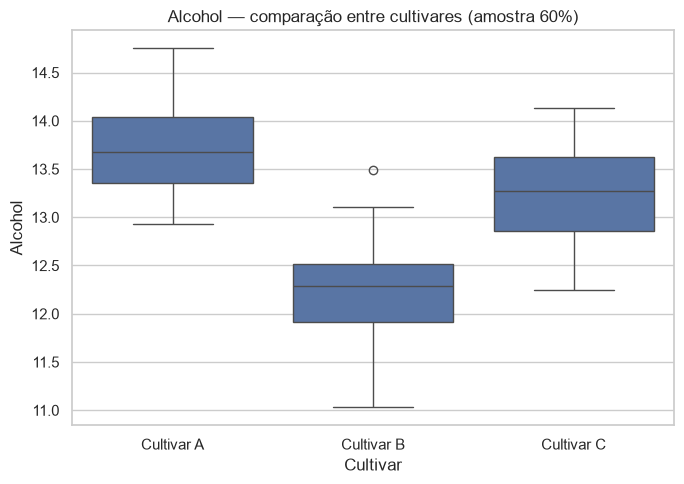

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=amostra_60, x="cultivar", y="alcohol", order=ORDEM_CULTIVARES, ax=ax)
ax.set_title("Alcohol — comparação entre cultivares (amostra 60%)")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Alcohol")
salvar_figura("q10_boxplot_alcohol.png")

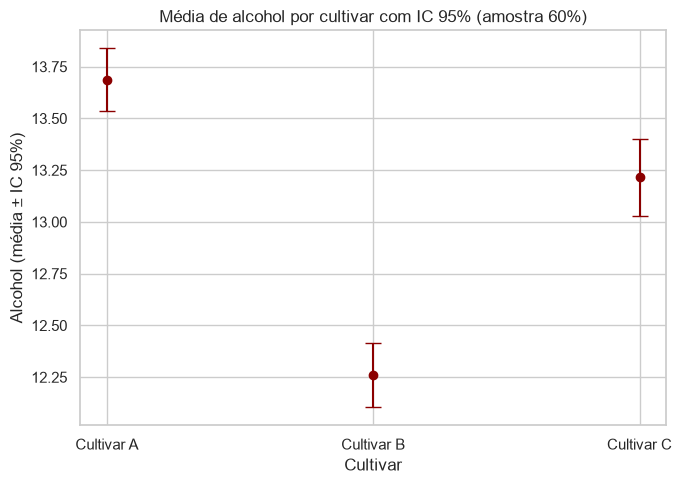

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
medias_plot = tabela_ic_alcohol["media"].to_numpy()
erros_plot = (tabela_ic_alcohol["ic95_superior"] - tabela_ic_alcohol["media"]).to_numpy()
ax.errorbar(ORDEM_CULTIVARES, medias_plot, yerr=erros_plot, fmt="o", capsize=6, color="darkred")
ax.set_title("Média de alcohol por cultivar com IC 95% (amostra 60%)")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Alcohol (média ± IC 95%)")
salvar_figura("q10_alcohol_media_ic95.png")

> **Interpretação.** Diferentemente das Questões 8 e 9, aqui **as premissas paramétricas foram
> integralmente atendidas**. O Shapiro-Wilk não rejeita a normalidade em nenhum dos três grupos:
> Cultivar A (W = 0,9785, p = 0,7091), Cultivar B (W = 0,9909, p = 0,9790) e Cultivar C (W = 0,9776,
> p = 0,7739), todos com p muito acima de α = 0,05, e o teste de Levene não rejeita a homogeneidade de
> variâncias (estatística = 0,3023, p = 0,7398). A decisão automática selecionou, portanto, a **ANOVA
> one-way**, que é o teste de maior poder estatístico quando suas condições são satisfeitas. Vale
> observar que `alcohol` é justamente a variável de menor CV médio do dataset (3,92%, item 5a) e de
> comportamento mais regular; o contraste com `malic_acid`, cujas premissas falharam em tudo na
> Questão 9, é instrutivo: a escolha do teste não é uma formalidade, ela decorre do comportamento
> empírico de cada variável.
>
> O resultado da ANOVA é **F = 90,0496 com p < 0,0001** (valor exato da ordem de 2,0 × 10⁻²³),
> altamente significativo. Leitura correta: se os três cultivares tivessem o mesmo teor alcoólico
> médio, a probabilidade de observar entre suas médias uma dispersão tão grande quanto a observada
> seria praticamente nula.
>
> O post-hoc de **Tukey HSD** (apropriado aqui, já que o teste principal é paramétrico) mostra que,
> desta vez, **os três pares diferem significativamente entre si**:
>
> - **A × B:** diferença de médias = −1,4279 (IC 95%: −1,6876 a −1,1682), p < 0,0001;
> - **B × C:** diferença de médias = +0,9570 (IC 95%: 0,6829 a 1,2311), p < 0,0001;
> - **A × C:** diferença de médias = −0,4709 (IC 95%: −0,7573 a −0,1844), p = 0,0005.
>
> A ordenação é **A (13,6874) > C (13,2166) > B (12,2595)**, e nenhum dos três intervalos de confiança
> das diferenças contém o zero. O contraste mais acentuado é A × B, com 1,43 ponto percentual de álcool
> (magnitude enologicamente expressiva), e mesmo o menor contraste, A × C (0,47 ponto), é
> significativo.
>
> O **tamanho de efeito é η² = 0,6339**: **63,4% de toda a variação do teor alcoólico é explicada pelo
> cultivar**. Pelos parâmetros convencionais (0,01 pequeno, 0,06 médio, 0,14 grande), trata-se de um
> efeito muito grande, mais que o dobro do ε² = 0,2827 obtido para `malic_acid` na Questão 9. A
> conclusão é significativa **e** relevante na prática, no sentido preciso da Questão 3(c).
>
> As médias com intervalo de confiança de 95% fecham o argumento: **A = 13,6874 [13,5367; 13,8382]**,
> **B = 12,2595 [12,1042; 12,4148]** e **C = 13,2166 [13,0305; 13,4026]**. Os intervalos são estreitos
> (amplitudes de apenas 0,30, 0,31 e 0,37 ponto percentual, respectivamente) e, sobretudo, **não se
> sobrepõem entre si**, com folgas confortáveis entre eles (de 12,4148 a 13,0305 e de 13,4026 a
> 13,5367). O gráfico de barras de erro torna essa separação imediatamente visível. Trata-se de
> evidência independente e convergente com o Tukey, e é ela que sustenta a discussão sobre política de
> preços do item (d).
>
> Um último achado merece destaque, por ser contraintuitivo. `alcohol` é a variável **menos** dispersa
> dentro de cada cultivar (CV médio de 3,92%, o menor dos 13) e, ao mesmo tempo, a que **melhor
> separa** os cultivares (η² = 0,6339). Não há contradição: o poder discriminante depende da razão
> entre a variabilidade *entre* grupos e a variabilidade *dentro* dos grupos. Baixa dispersão interna
> combinada com médias distantes produz separação nítida. O `malic_acid` ilustra o oposto: é a
> variável de maior CV (39,81%) e, apesar disso, só distingue um dos três cultivares. A lição prática
> é que, para classificar lotes por cultivar, deve-se privilegiar variáveis estáveis dentro do grupo e
> distantes entre grupos, não simplesmente as mais variáveis.

**d)** Redija uma conclusão final, com no máximo 15 linhas, integrando: a
representatividade da amostra construída no item (a), a redundância de variáveis
identificada no item (b), e se a diferença no teor alcoólico encontrada no item (c)
sustenta estatisticamente uma política de preços diferenciada por cultivar. A conclusão
deve referenciar explicitamente as evidências estatísticas obtidas, não opiniões
pessoais sobre o vinho.

> **Conclusão final.**
>
> A amostra estratificada de 60% (n = 107: 35 A, 43 B, 29 C) reproduziu as proporções populacionais com
> desvio máximo de 0,44 p.p. e as médias de 12 das 13 variáveis dentro de ±1,7%; o maior desvio,
> `malic_acid` (+6,85%), recai justamente sobre a variável de maior CV médio (39,81%), como prevê a
> relação σ_X̄ = σ/√n. A amostra é, portanto, representativa em nível médio e também em estrutura de
> covariância, pois o bloco fenólico do item (b) reproduz o heatmap da população (item 7d). Quanto à
> redundância, o par mais redundante fora dos já tratados na Questão 7 é **`total_phenols` ×
> `od280/od315_of_diluted_wines` (r = 0,7047)**, com r² ≈ 0,50. Quanto ao teor alcoólico, as premissas
> paramétricas foram atendidas (Shapiro-Wilk p = 0,7091/0,9790/0,7739; Levene p = 0,7398), e a **ANOVA
> one-way** devolveu **F = 90,0496, p < 0,0001**, isto é, sob a hipótese de teores médios iguais, uma
> dispersão entre médias como a observada seria praticamente impossível. O **Tukey HSD** separa os
> **três** pares (A−B = −1,4279; B−C = +0,9570; A−C = −0,4709, todos com IC 95% sem o zero), com
> **η² = 0,6339**: 63,4% da variação do álcool é explicada pelo cultivar, e os IC 95% das médias
> (A 13,69; C 13,22; B 12,26) não se sobrepõem.
>
> **Resposta à diretoria sobre preços.** Sim, a evidência sustenta estatisticamente a diferenciação por
> cultivar: o efeito não é apenas detectável, é grande (η² = 0,6339) e materialmente expressivo (1,43
> ponto percentual entre A e B). Ressalva necessária: a estatística demonstra que os cultivares são
> **distinguíveis** pelo teor alcoólico, não que o mercado remunere essa diferença; precificar exige
> dados de preço e demanda, ausentes desta base.
>
> **Resposta à diretoria sobre a redução de testes.** Viável de forma parcial e em duas frentes. (i) *Por
> amostragem:* 60% dos lotes, estratificados por cultivar, bastaram para recuperar as médias
> populacionais dentro de ±1,7%, o que dispensa o exame censitário, desde que a seleção seja
> estratificada, e nunca por conveniência (Questão 2a). (ii) *Por variável:* dentro do bloco fenólico
> há sobreposição de informação, mas r = 0,7047 significa r² ≈ 0,50, ou seja, **metade da variância
> ainda é específica**; a recomendação é suprimir uma medida do bloco, não o bloco inteiro. Devem ser
> mantidas em todos os lotes as variáveis de alta dispersão (`malic_acid`, CV 39,81%) e as de alto
> poder discriminante (`alcohol`, η² = 0,6339), e convém revalidar a redundância **dentro** de cada
> cultivar, pois parte das correlações agregadas decorre da mistura de grupos (item 7d).